# Análise de Simulações OpenDC — Topologia m7i.xlarge (Amazon EC2)

## Contextualização do Projeto

Este notebook integra a fase de simulação computacional do projeto de Iniciação
Científica intitulado *Gêmeo Digital Adaptável ao Cliente para Monitoramento de
Consumo de Recursos em Infraestrutura de Nuvem*, desenvolvido no Inteli — Instituto de Tecnologia e Liderança sob orientação do Prof. Reginaldo Arakaki e coorientação da Prof.ª Fabiana Martins de Oliveira.

O projeto investiga a hipótese de que sistemas de monitoramento baseados em
gêmeos digitais, quando adaptados às características operacionais e
arquiteturais específicas de cada cliente, produzem resultados mais precisos e
contextualmente relevantes do que abordagens genéricas. A adaptabilidade é
tratada como variável central: o sistema é configurável segundo perfis de uso,
prioridades estratégicas e padrões arquiteturais do cliente, permitindo que
thresholds, modelos de custo e regras de análise reflitam o contexto particular
de cada organização.

## Etapa do Projeto: Simulação e Coleta de Dados de Referência

O trabalho está estruturado em quatro fases ao longo de doze meses. Este
notebook corresponde à **Fase 3**, cujo escopo abrange a especificação e
execução dos cenários arquiteturais no simulador OpenDC, e à transição para
a **Fase 4**, que contempla a implementação do sistema de análise adaptável e
a condução dos experimentos comparativos controlados.

Nesta etapa, foram definidas **seis topologias de infraestrutura**, cada uma
modelando uma configuração distinta de data center virtual no OpenDC. A
escolha das topologias foi orientada pela diversidade de perfis de instâncias
Amazon EC2, buscando cobrir diferentes combinações de capacidade computacional,
consumo energético e configuração de memória, de modo a viabilizar
comparações entre configurações genéricas e adaptadas ao perfil do cliente
modelado. O presente notebook documenta os experimentos realizados sobre
a topologia `m7i.xlarge`, identificada como a aproximação mais adequada ao
perfil do case de e-commerce de porte médio definido no projeto.

## Caso de Estudo: E-commerce de Porte Médio

O cliente modelado neste projeto é uma empresa fictícia de varejo eletrônico
denominada *E-Shop Brasil*, escolhida por reunir características que tornam o
problema de monitoramento adaptável especialmente relevante: alta variabilidade
de carga ao longo do ciclo operacional, sensibilidade a custos e padrões
arquiteturais bem estabelecidos na literatura. Essa escolha permitiu delimitar
com precisão os perfis de uso e os critérios de eficiência que o gêmeo digital
deve monitorar, em contraposição a abordagens de propósito geral.

A topologia configurada no OpenDC consiste em um cluster de 100 hosts baseados
na instância `m7i.xlarge` (4 vCPUs, 16 GiB de memória RAM, uso geral de sétima
geração), distribuídos em racks com parâmetros de PUE, capacidade de CPU e
políticas de alocação calibrados para este perfil. Sobre essa topologia, foram
gerados e executados **7 workloads** representativos do ciclo operacional do
e-commerce, cobrindo desde o tráfego mínimo de madrugada até o pico máximo
associado a eventos como a Black Friday.

## O que este Notebook Realiza

A partir dos arquivos `.parquet` produzidos pelo OpenDC como saída das
simulações, este notebook percorre as seguintes etapas de forma progressiva:

1. **Descoberta e inspeção estrutural** dos arquivos de saída por cenário
   (`host`, `powerSource`, `service`, `task`), com levantamento do esquema
   e dicionário analítico de cada nível de granularidade.
2. **Limpeza e padronização** dos dados, incluindo derivação de unidades
   (conversão de milissegundos, Joules e frações para segundos, kWh e
   percentuais), e unificação dos sete cenários em DataFrames consolidados.
3. **Análise estatística e visual** dos resultados por cenário, abrangendo
   utilização de CPU, consumo energético, latência de tasks, taxa de
   completude, saturação do escalonador e balanceamento de carga entre hosts.
4. **Derivação de métricas compostas** de eficiência operacional e custo
   estimado, utilizando preços oficiais da AWS Pricing API.
5. **Consolidação do dataset final** e preparação da base estruturada para
   as etapas seguintes: modelagem preditiva de energia, custo e latência;
   desenvolvimento do sistema de recomendação de configurações; e integração
   com o gêmeo digital adaptável.

Os resultados produzidos aqui constituem a base empírica sobre a qual os
experimentos comparativos entre configurações genéricas e adaptadas serão
conduzidos nas fases subsequentes do projeto.

---

**Instância simulada:** `m7i.xlarge` — 4 vCPUs · 16 GiB RAM  
**Topologias definidas no projeto:** 6  
**Cenários executados nesta topologia:** 7 workloads (índices 0–6)  
**Seed:** `seed=0`  
**Arquivos por cenário:** `host`, `powerSource`, `service`, `task`

---
## Bloco 2 — Configuração: Imports e Paths

In [114]:
import warnings
from datetime import datetime
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (13, 5)

print('Imports concluídos.')

Imports concluídos.


In [115]:
# ── Caminhos do projeto ───────────────────────────────────────────────────────
PROJECT_ROOT    = Path('.')
EXPERIMENT_NAME = 'm7ixlarge_generated_workloads_experiment'
RAW_OUTPUT_DIR  = PROJECT_ROOT / 'output' / EXPERIMENT_NAME / 'raw-output'
SEED_FOLDER     = 'seed=0'

FIGURES_DIR  = PROJECT_ROOT / 'figures'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_FILES = ['host', 'powerSource', 'service', 'task']

# ── Preço EC2 — carregado do snapshot da AWS Pricing API ─────────────────────
# Execute fetch_pricing.py primeiro para gerar o arquivo pricing/pricing_metadata.json
PRICING_FILE = PROJECT_ROOT / 'pricing' / 'pricing_metadata.json'

if PRICING_FILE.exists():
    _pricing = json.load(open(PRICING_FILE))
    EC2_PRICE_USD_PER_H = _pricing['price_usd_per_h']
    _pricing_date       = _pricing['accessed_date']
    _pricing_source     = _pricing['source_url']
    print(f'   Preço EC2 carregado do snapshot:')
    print(f'   {_pricing["instance_type"]} ({_pricing["region_name"]}) = USD {EC2_PRICE_USD_PER_H}/h')
    print(f'   Fonte  : {_pricing_source}')
    print(f'   Acesso : {_pricing_date}')
else:
    # Fallback com aviso — rode fetch_pricing.py para obter o valor oficial
    EC2_PRICE_USD_PER_H = 0.1904
    print(f'   pricing/pricing_metadata.json não encontrado.')
    print(f'   Usando valor fallback: USD {EC2_PRICE_USD_PER_H}/h (m7i.xlarge us-east-1)')
    print(f'   Execute: python fetch_pricing.py')
    print(f'   Para obter o preço oficial da AWS Pricing API.')

# Constantes de conversão
MS_TO_S  = 1_000
MS_TO_H  = 3_600_000
J_TO_KWH = 1 / 3_600_000

print(f'\n RAW_OUTPUT_DIR : {RAW_OUTPUT_DIR.resolve()}')
print(f' FIGURES_DIR    : {FIGURES_DIR.resolve()}')
print(f' DATASETS_DIR   : {DATASETS_DIR.resolve()}')

   pricing/pricing_metadata.json não encontrado.
   Usando valor fallback: USD 0.1904/h (m7i.xlarge us-east-1)
   Execute: python fetch_pricing.py
   Para obter o preço oficial da AWS Pricing API.

 RAW_OUTPUT_DIR : C:\Users\Rodrigo\Desktop\opendc-demos-v4\output\m7ixlarge_generated_workloads_experiment\raw-output
 FIGURES_DIR    : C:\Users\Rodrigo\Desktop\opendc-demos-v4\figures
 DATASETS_DIR   : C:\Users\Rodrigo\Desktop\opendc-demos-v4\datasets


---
## Bloco 3 — Descoberta dos Arquivos Disponíveis

In [116]:
scenario_dirs = sorted(
    [p for p in RAW_OUTPUT_DIR.iterdir() if p.is_dir() and p.name.isdigit()],
    key=lambda p: int(p.name)
)

print(f' {len(scenario_dirs)} cenário(s) encontrado(s)\n')
for s in scenario_dirs:
    seed_path = s / SEED_FOLDER
    parquets  = sorted(seed_path.glob('*.parquet')) if seed_path.exists() else []
    print(f'   {s.name}/{SEED_FOLDER}/')
    for p in parquets:
        print(f'       ├── {p.name:25s}  ({p.stat().st_size/1024:.1f} KB)')

# Dicionário: 'workload_0' → Path .../0/seed=0
SCENARIOS = {
    f'workload_{s.name}': s / SEED_FOLDER
    for s in scenario_dirs
    if (s / SEED_FOLDER).exists()
}
SCENARIO_NAMES = list(SCENARIOS.keys())
palette = sns.color_palette('tab10', n_colors=len(SCENARIO_NAMES))

print(f'\n Cenários mapeados: {SCENARIO_NAMES}')

 7 cenário(s) encontrado(s)

   0/seed=0/
       ├── host.parquet               (5.9 KB)
       ├── powerSource.parquet        (1.7 KB)
       ├── service.parquet            (1.7 KB)
       ├── task.parquet               (7.1 KB)
   1/seed=0/
       ├── host.parquet               (5.9 KB)
       ├── powerSource.parquet        (1.7 KB)
       ├── service.parquet            (1.7 KB)
       ├── task.parquet               (7.2 KB)
   2/seed=0/
       ├── host.parquet               (6.0 KB)
       ├── powerSource.parquet        (1.7 KB)
       ├── service.parquet            (1.7 KB)
       ├── task.parquet               (7.4 KB)
   3/seed=0/
       ├── host.parquet               (6.1 KB)
       ├── powerSource.parquet        (1.7 KB)
       ├── service.parquet            (1.7 KB)
       ├── task.parquet               (7.8 KB)
   4/seed=0/
       ├── host.parquet               (6.2 KB)
       ├── powerSource.parquet        (1.7 KB)
       ├── service.parquet            (1.7 KB)
       ├── ta

---
## Bloco 4 — Exploração Estrutural dos Parquets

In [117]:
def inspect_parquet(path: Path, n_rows: int = 3) -> pd.DataFrame:
    df = pd.read_parquet(path)
    print(f'\n{"="*65}')
    print(f'  {path.name}   ({len(df):,} linhas × {len(df.columns)} colunas)')
    print(f'\n   {"Coluna":<38} {"dtype":<14} nulos')
    print(f'   {"-"*60}')
    for col, dtype in df.dtypes.items():
        nulls = df[col].isna().sum()
        tag   = f'     {nulls}' if nulls > 0 else ''
        print(f'   {col:<38} {str(dtype):<14}{tag}')
    print()
    display(df.head(n_rows))
    return df

ref_path = SCENARIOS['workload_0']
print(f' Referência: workload_0  →  {ref_path}\n')
raw = {f: inspect_parquet(ref_path / f'{f}.parquet') for f in PARQUET_FILES}

 Referência: workload_0  →  output\m7ixlarge_generated_workloads_experiment\raw-output\0\seed=0


  host.parquet   (100 linhas × 24 colunas)

   Coluna                                 dtype          nulos
   ------------------------------------------------------------
   timestamp                              int64         
   timestamp_absolute                     int64         
   host_name                              object        
   cluster_name                           object        
   core_count                             int32         
   mem_capacity                           int64         
   tasks_terminated                       int32         
   tasks_running                          int32         
   tasks_error                            int32         
   tasks_invalid                          int32         
   cpu_capacity                           float32       
   cpu_usage                              float32       
   cpu_demand                             float

,timestamp,timestamp_absolute,host_name,cluster_name,core_count,mem_capacity,tasks_terminated,tasks_running,tasks_error,tasks_invalid,cpu_capacity,cpu_usage,cpu_demand,cpu_utilization,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,power_draw,energy_usage,embodied_carbon,uptime,downtime,boot_time
0,10174,10347,m7i_xlarge_host-2,cluster_m7i,4,16384,0,0,0,0,12000.0000,0.0000,0.0000,0.0000,0,10174,0,0,70.0000,712.1802,0.0645,10174,0,173
1,10174,10347,m7i_xlarge_host-1,cluster_m7i,4,16384,0,0,0,0,12000.0000,0.0000,0.0000,0.0000,0,10174,0,0,70.0000,712.1807,0.0645,10174,0,173
2,10174,10347,m7i_xlarge_host-4,cluster_m7i,4,16384,0,0,0,0,12000.0000,0.0000,0.0000,0.0000,0,10174,0,0,70.0000,712.1801,0.0645,10174,0,173



  powerSource.parquet   (1 linhas × 8 colunas)

   Coluna                                 dtype          nulos
   ------------------------------------------------------------
   timestamp                              int64         
   timestamp_absolute                     int64         
   source_name                            object        
   cluster_name                           object        
   power_draw                             float32       
   energy_usage                           float32       
   carbon_intensity                       float32       
   carbon_emission                        float32       



,timestamp,timestamp_absolute,source_name,cluster_name,power_draw,energy_usage,carbon_intensity,carbon_emission
0,10174,10347,PowerSource,cluster_m7i,7000.0034,71218.0000,0.0000,0.0000



  service.parquet   (1 linhas × 9 colunas)

   Coluna                                 dtype          nulos
   ------------------------------------------------------------
   timestamp                              int64         
   timestamp_absolute                     int64         
   hosts_up                               int32         
   hosts_down                             int32         
   tasks_total                            int32         
   tasks_pending                          int32         
   tasks_active                           int32         
   tasks_completed                        int32         
   tasks_terminated                       int32         



,timestamp,timestamp_absolute,hosts_up,hosts_down,tasks_total,tasks_pending,tasks_active,tasks_completed,tasks_terminated
0,10174,10347,100,0,10,0,0,10,0



  task.parquet   (10 linhas × 30 colunas)

   Coluna                                 dtype          nulos
   ------------------------------------------------------------
   timestamp                              int64         
   timestamp_absolute                     int64         
   task_id                                int32         
   task_name                              object        
   host_name                              object        
   mem_capacity                           int64         
   cpu_count                              int32         
   cpu_limit                              float32       
   cpu_usage                              float32       
   cpu_demand                             float32       
   cpu_time_active                        int64         
   cpu_time_idle                          int64         
   cpu_time_steal                         int64         
   cpu_time_lost                          int64         
   gpu_count                   

,timestamp,timestamp_absolute,task_id,task_name,host_name,mem_capacity,cpu_count,cpu_limit,cpu_usage,cpu_demand,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,gpu_count,gpu_limit,gpu_usage,gpu_demand,gpu_time_active,gpu_time_idle,gpu_time_steal,gpu_time_lost,uptime,downtime,num_failures,num_pauses,schedule_time,submission_time,finish_time,task_state
0,10174,10347,208,,m7i_xlarge_host-3,4,1,0.0000,0.0000,0.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,6000,5498,6048,COMPLETED
1,10174,10347,17,,m7i_xlarge_host,1,1,0.0000,0.0000,0.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,173,176,COMPLETED
2,10174,10347,82,,m7i_xlarge_host-1,1,2,0.0000,0.0000,0.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,2000,2000,2149,COMPLETED


---
## Bloco 5 — Dicionário Analítico

### `host.parquet` — nível de host, por timestamp

| Coluna | Interpretação | Papel |
|--------|--------------|-------|
| `timestamp` | Tempo relativo da simulação (ms) | Temporal |
| `timestamp_absolute` | Tempo absoluto da simulação (ms) | Temporal |
| `host_name` | Identificador do host | ID |
| `cluster_name` | Nome do cluster | ID |
| `core_count` | Número de núcleos (4 para m7i.xlarge) | Topologia |
| `mem_capacity` | Capacidade de memória em MiB (16384 = 16 GiB) | Topologia |
| `tasks_running` | Tasks em execução neste host neste instante | Carga |
| `tasks_terminated` | Tasks encerradas neste host | Carga |
| `tasks_error` / `tasks_invalid` | Tasks com erro ou inválidas | Qualidade |
| `cpu_capacity` | Capacidade total de CPU | Topologia |
| `cpu_usage` | CPU em uso efetivo | Métrica principal |
| `cpu_demand` | CPU demandada pelas tasks | Métrica principal |
| `cpu_utilization` | Razão uso/capacidade — 0 a 1 | Métrica principal |
| `cpu_time_active/idle/steal/lost` | Decomposição do tempo de CPU em ms | Diagnóstico |
| `power_draw` | Potência instantânea do host em Watts | Energia |
| `energy_usage` | Energia acumulada do host em Joules | Energia |
| `embodied_carbon` | Carbono incorporado estimado | Sustentabilidade |
| `uptime` / `downtime` / `boot_time` | Tempo ativo, inativo e de boot em ms | Disponibilidade |

### `powerSource.parquet` — nível de cluster, por timestamp

| Coluna | Interpretação | Papel |
|--------|--------------|-------|
| `timestamp` / `timestamp_absolute` | Tempo em ms | Temporal |
| `source_name` / `cluster_name` | Identificadores | ID |
| `power_draw` | Potência total do cluster em Watts | Energia |
| `energy_usage` | Energia acumulada do cluster em Joules | Energia |
| `carbon_intensity` | Intensidade de carbono em gCO₂/kWh | Sustentabilidade |
| `carbon_emission` | Emissão de carbono em gCO₂ | Sustentabilidade |

### `service.parquet` — nível de serviço, por timestamp

| Coluna | Interpretação | Papel |
|--------|--------------|-------|
| `timestamp` / `timestamp_absolute` | Tempo em ms | Temporal |
| `hosts_up` / `hosts_down` | Hosts ativos e inativos | Disponibilidade |
| `tasks_total` | Total de tasks no sistema | Carga |
| `tasks_pending` | Tasks aguardando escalonamento — indicador de saturação | Saturação |
| `tasks_active` | Tasks em execução | Carga |
| `tasks_completed` | Tasks concluídas com sucesso | Desempenho |
| `tasks_terminated` | Tasks encerradas em geral | Desempenho |

### `task.parquet` — nível de task, por timestamp

| Coluna | Interpretação | Papel |
|--------|--------------|-------|
| `timestamp` / `timestamp_absolute` | Tempo em ms | Temporal |
| `task_id` / `task_name` | Identificadores da task | ID |
| `host_name` | Host que executou a task | ID |
| `mem_capacity` | Memória alocada em MiB | Recurso |
| `cpu_count` / `cpu_limit` | CPUs alocadas e limite | Recurso |
| `cpu_usage` / `cpu_demand` | CPU efetivamente em uso e demandada | Métrica |
| `cpu_time_active/idle/steal/lost` | Decomposição do tempo de CPU em ms | Diagnóstico |
| `gpu_*` | Métricas de GPU — não utilizadas neste experimento (zeros) | Ignorar |
| `uptime` / `downtime` | Tempo ativo e inativo da task em ms | Desempenho |
| `num_failures` / `num_pauses` | Contagem de falhas e pausas | Qualidade |
| `submission_time` | Instante de submissão em ms | Latência |
| `schedule_time` | Instante de escalonamento em ms | Latência |
| `finish_time` | Instante de conclusão em ms | Latência |
| `task_state` | Estado final — ex: `COMPLETED` | Qualidade |

---
## Bloco 6 — Limpeza e Padronização

As funções a seguir padronizam os arquivos `.parquet` de cada nível de
granularidade, derivando unidades operacionais a partir dos valores brutos
do simulador (milissegundos para segundos, Joules para kWh, frações para
percentuais) e adicionando a coluna `scenario` para identificação dos
cenários ao longo de todas as análises. Em seguida, os sete cenários são
carregados e concatenados em DataFrames unificados, que servem de base
para todo o Bloco 7.

In [118]:
def load_host(path: Path, scenario: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df['scenario']     = scenario
    df['time_s']       = df['timestamp'] / MS_TO_S
    df['energy_kwh']   = df['energy_usage'] * J_TO_KWH
    df['cpu_util_pct'] = df['cpu_utilization'] * 100
    df['uptime_h']     = df['uptime'] / MS_TO_H
    return df

def load_power(path: Path, scenario: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df['scenario']   = scenario
    df['time_s']     = df['timestamp'] / MS_TO_S
    df['energy_kwh'] = df['energy_usage'] * J_TO_KWH
    return df

def load_service(path: Path, scenario: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df['scenario']        = scenario
    df['time_s']          = df['timestamp'] / MS_TO_S
    df['pending_rate']    = df['tasks_pending']   / df['tasks_total'].replace(0, np.nan)
    df['completion_rate'] = df['tasks_completed'] / df['tasks_total'].replace(0, np.nan)
    return df

def load_task(path: Path, scenario: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df['scenario']     = scenario
    df['time_s']       = df['timestamp'] / MS_TO_S
    df['wait_time_s']  = ((df['schedule_time']  - df['submission_time']) / MS_TO_S).clip(lower=0)
    df['exec_time_s']  = ((df['finish_time']    - df['schedule_time'])   / MS_TO_S).clip(lower=0)
    df['total_time_s'] = ((df['finish_time']    - df['submission_time']) / MS_TO_S).clip(lower=0)
    df['completed']    = (df['task_state'] == 'COMPLETED').astype(int)
    return df

print('  Funções de limpeza definidas.')

  Funções de limpeza definidas.


In [119]:
host_dfs, power_dfs, svc_dfs, task_dfs = [], [], [], []

for sname, spath in SCENARIOS.items():
    print(f' {sname}  →  {spath}')
    host_dfs.append (load_host   (spath / 'host.parquet',        sname))
    power_dfs.append(load_power  (spath / 'powerSource.parquet', sname))
    svc_dfs.append  (load_service(spath / 'service.parquet',     sname))
    task_dfs.append (load_task   (spath / 'task.parquet',        sname))

df_host  = pd.concat(host_dfs,  ignore_index=True)
df_power = pd.concat(power_dfs, ignore_index=True)
df_svc   = pd.concat(svc_dfs,   ignore_index=True)
df_task  = pd.concat(task_dfs,  ignore_index=True)

print('\n  DataFrames unificados:')
for label, df in [('host', df_host), ('powerSource', df_power), ('service', df_svc), ('task', df_task)]:
    print(f'   {label:15s} → {len(df):>8,} linhas | {df["scenario"].nunique()} cenários')

 workload_0  →  output\m7ixlarge_generated_workloads_experiment\raw-output\0\seed=0
 workload_1  →  output\m7ixlarge_generated_workloads_experiment\raw-output\1\seed=0
 workload_2  →  output\m7ixlarge_generated_workloads_experiment\raw-output\2\seed=0
 workload_3  →  output\m7ixlarge_generated_workloads_experiment\raw-output\3\seed=0
 workload_4  →  output\m7ixlarge_generated_workloads_experiment\raw-output\4\seed=0
 workload_5  →  output\m7ixlarge_generated_workloads_experiment\raw-output\5\seed=0
 workload_6  →  output\m7ixlarge_generated_workloads_experiment\raw-output\6\seed=0

  DataFrames unificados:
   host            →      700 linhas | 7 cenários
   powerSource     →        7 linhas | 7 cenários
   service         →        7 linhas | 7 cenários
   task            →      960 linhas | 7 cenários


---
## Bloco 7 — Análise Estatística e Visual

### 7.0 — Tabela-resumo por cenário (visão consolidada)

A tabela a seguir consolida as principais métricas agregadas por cenário,
oferecendo uma visão comparativa de alto nível antes das análises individuais.
Os valores permitem identificar rapidamente a progressão de carga entre os
workloads e servem como referência para as seções subsequentes.

In [120]:
# Ordem canônica dos cenários por volume de carga (10 → 350 tasks)
SCENARIO_ORDER = SCENARIO_NAMES   # já estão em ordem crescente (workload_0 ... workload_6)
N_TASKS_PER_SCENARIO = {s: len(df_task[df_task['scenario'] == s]) for s in SCENARIO_ORDER}

summary_rows = []
for s in SCENARIO_ORDER:
    h  = df_host [df_host ['scenario'] == s]
    pw = df_power[df_power['scenario'] == s]
    sv = df_svc  [df_svc  ['scenario'] == s]
    tk = df_task [df_task ['scenario'] == s]
    summary_rows.append({
        'Cenário':           s,
        'N tasks':           len(tk),
        'Duração sim (s)':   tk['finish_time'].max() / 1000,
        'CPU uso médio':     h['cpu_usage'].mean().round(4),
        'CPU util (%)':      h['cpu_util_pct'].mean().round(4),
        'Power draw (W)':    h['power_draw'].mean().round(2),
        'Energia (kWh)':     pw['energy_kwh'].iloc[0].round(6),
        'Tasks complet.':    int(sv['tasks_completed'].iloc[0]),
        'Wait médio (s)':    tk['wait_time_s'].mean().round(3),
        'Exec médio (s)':    tk['exec_time_s'].mean().round(3),
        'Total médio (s)':   tk['total_time_s'].mean().round(3),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Cenário')
print('  Tabela-resumo por cenário:')
display(df_summary)

  Tabela-resumo por cenário:


,N tasks,Duração sim (s),CPU uso médio,CPU util (%),Power draw (W),Energia (kWh),Tasks complet.,Wait médio (s),Exec médio (s),Total médio (s)
Cenário,,,,,,,,,,
workload_0,10,10.1740,0.0031,0.0000,70.0000,0.0198,10,0.3750,0.0900,0.4460
workload_1,25,10.3210,0.0031,0.0000,70.0000,0.0201,25,0.2970,0.2030,0.4740
workload_2,50,8.3420,0.0031,0.0000,70.0000,0.0162,50,0.4940,0.2210,0.7130
workload_3,100,5.4970,0.0050,0.0000,70.0000,0.0107,100,0.4360,0.2710,0.7040
workload_4,175,4.5470,0.0055,0.0000,70.0000,0.0088,175,0.4670,0.2950,0.7600
workload_5,250,3.5990,0.0044,0.0000,70.0000,0.0070,250,0.4250,0.3170,0.7400
workload_6,350,3.6460,0.0063,0.0001,70.0000,0.0071,350,0.5430,0.3580,0.9010


In [121]:
df_summary.to_csv(DATASETS_DIR / 'summary_por_cenario.csv', index=True)
df_summary.to_excel(DATASETS_DIR / 'summary_por_cenario.xlsx')  # opcional
print('Saved datasets/summary_por_cenario.csv')

Saved datasets/summary_por_cenario.csv


In [122]:
print(df_summary.to_markdown())

| Cenário    |   N tasks |   Duração sim (s) |   CPU uso médio |   CPU util (%) |   Power draw (W) |   Energia (kWh) |   Tasks complet. |   Wait médio (s) |   Exec médio (s) |   Total médio (s) |
|:-----------|----------:|------------------:|----------------:|---------------:|-----------------:|----------------:|-----------------:|-----------------:|-----------------:|------------------:|
| workload_0 |        10 |            10.174 |          0.0031 |         0      |               70 |        0.019783 |               10 |            0.375 |            0.09  |             0.446 |
| workload_1 |        25 |            10.321 |          0.0031 |         0      |               70 |        0.020069 |               25 |            0.297 |            0.203 |             0.474 |
| workload_2 |        50 |             8.342 |          0.0031 |         0      |               70 |        0.016221 |               50 |            0.494 |            0.221 |             0.713 |
| workload_3 |      

### 7.1 — Comparação de métricas agregadas por cenário

A utilização de CPU é o indicador primário de eficiência computacional no
contexto deste case. Valores sistematicamente baixos indicam
superdimensionamento da infraestrutura, enquanto a ausência de crescimento
proporcional à carga — observável nos cenários de maior volume, onde o
cluster opera com todos os hosts ativos — revela os limites de capacidade
de alocação da topologia configurada. A análise a seguir examina esse
comportamento ao longo dos sete cenários, do tráfego mínimo de madrugada
aos regimes de alta demanda representativos de eventos sazonais.

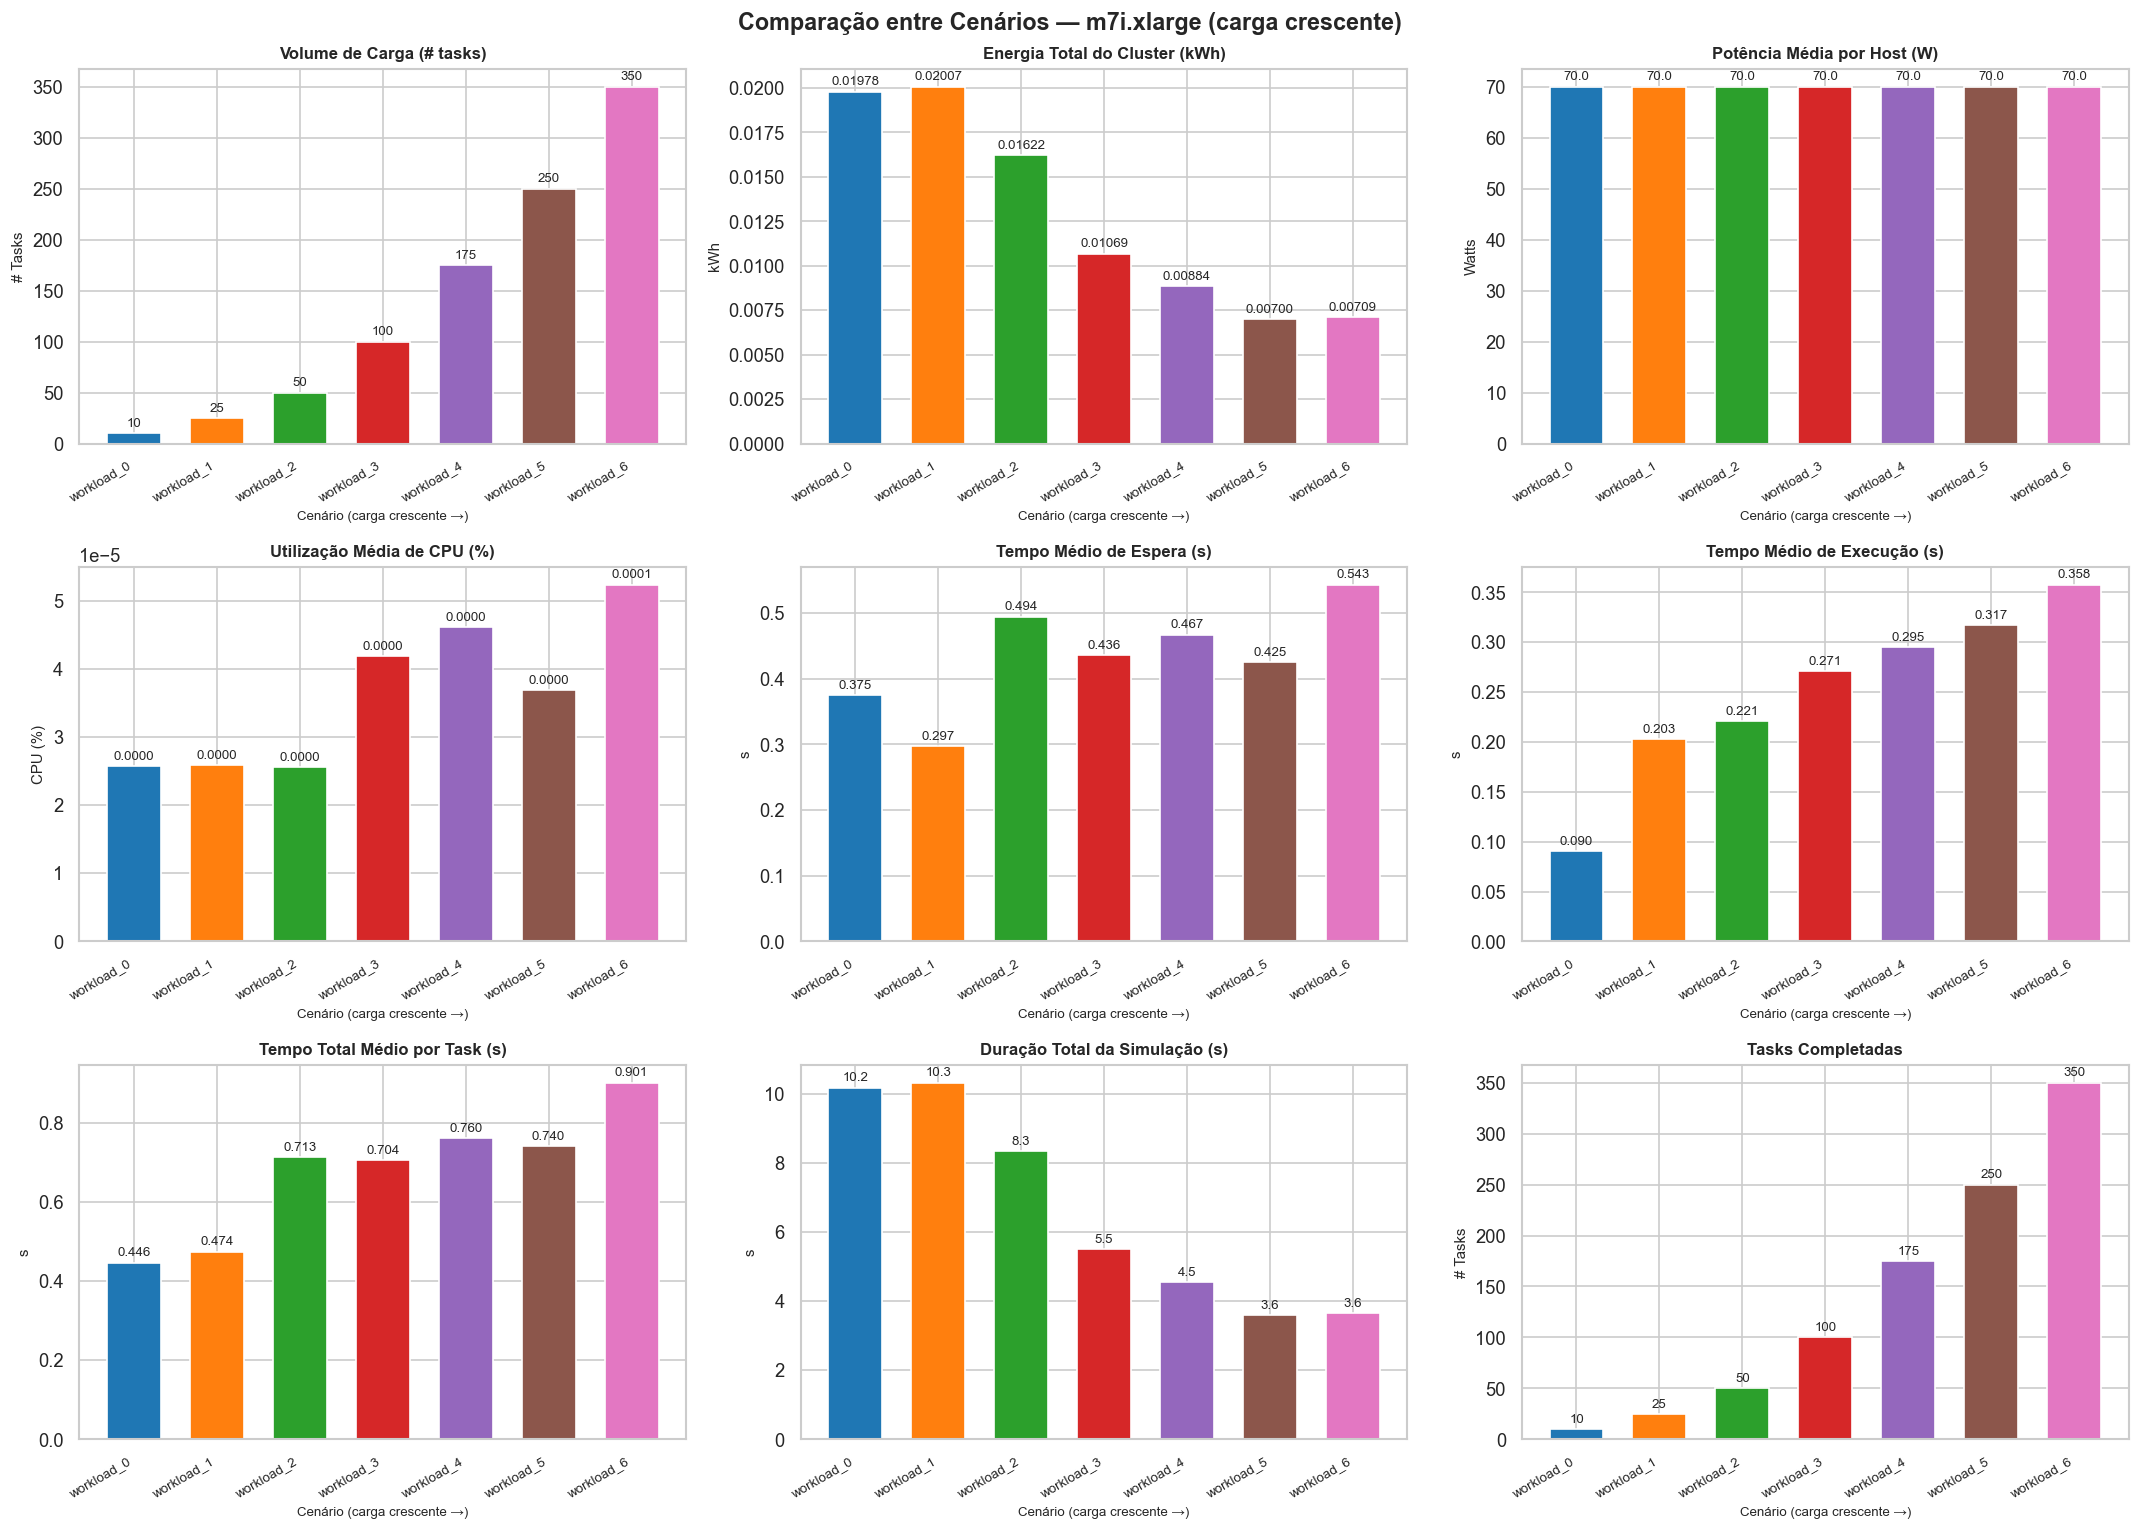

Saved figures/bar_comparison_full.png


In [123]:
# Eixo x ordenado por volume crescente de tasks
x_labels = SCENARIO_ORDER
x_pos    = np.arange(len(x_labels))
colors   = palette

def bar_scenario(ax, values, title, ylabel, fmt='{:.3f}', color_bars=True):
    bars = ax.bar(x_pos, values, color=colors if color_bars else '#4C72B0', edgecolor='white', width=0.65)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(values)*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Cenário (carga crescente →)', fontsize=8)

n_tasks_vals    = [N_TASKS_PER_SCENARIO[s] for s in SCENARIO_ORDER]
energy_vals     = [df_power[df_power['scenario']==s]['energy_kwh'].iloc[0]  for s in SCENARIO_ORDER]
power_vals      = [df_host[df_host['scenario']==s]['power_draw'].mean()     for s in SCENARIO_ORDER]
cpu_util_vals   = [df_host[df_host['scenario']==s]['cpu_util_pct'].mean()   for s in SCENARIO_ORDER]
wait_vals       = [df_task[df_task['scenario']==s]['wait_time_s'].mean()    for s in SCENARIO_ORDER]
exec_vals       = [df_task[df_task['scenario']==s]['exec_time_s'].mean()    for s in SCENARIO_ORDER]
total_vals      = [df_task[df_task['scenario']==s]['total_time_s'].mean()   for s in SCENARIO_ORDER]
duration_vals   = [df_task[df_task['scenario']==s]['finish_time'].max()/1000 for s in SCENARIO_ORDER]
completed_vals  = [df_svc[df_svc['scenario']==s]['tasks_completed'].iloc[0] for s in SCENARIO_ORDER]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Comparação entre Cenários — m7i.xlarge (carga crescente)', fontsize=14, fontweight='bold')

bar_scenario(axes[0,0], n_tasks_vals,   'Volume de Carga (# tasks)',          '# Tasks',  '{:.0f}')
bar_scenario(axes[0,1], energy_vals,    'Energia Total do Cluster (kWh)',      'kWh',      '{:.5f}')
bar_scenario(axes[0,2], power_vals,     'Potência Média por Host (W)',         'Watts',    '{:.1f}')
bar_scenario(axes[1,0], cpu_util_vals,  'Utilização Média de CPU (%)',         'CPU (%)',  '{:.4f}')
bar_scenario(axes[1,1], wait_vals,      'Tempo Médio de Espera (s)',           's',        '{:.3f}')
bar_scenario(axes[1,2], exec_vals,      'Tempo Médio de Execução (s)',         's',        '{:.3f}')
bar_scenario(axes[2,0], total_vals,     'Tempo Total Médio por Task (s)',      's',        '{:.3f}')
bar_scenario(axes[2,1], duration_vals,  'Duração Total da Simulação (s)',      's',        '{:.1f}')
bar_scenario(axes[2,2], completed_vals, 'Tasks Completadas',                   '# Tasks',  '{:.0f}')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'bar_comparison_full.png', dpi=150)
plt.show()
print('Saved figures/bar_comparison_full.png')

### 7.2 — Análise temporal reconstruída a partir dos timestamps das tasks

Como os arquivos `.parquet` do OpenDC contêm um único snapshot por cenário,
a dimensão temporal da simulação não está disponível diretamente nas tabelas
de `host`, `powerSource` ou `service`. A evolução ao longo do tempo é
reconstruída a partir dos campos `submission_time`, `schedule_time` e
`finish_time` presentes em `task.parquet`, que registram os instantes
individuais de cada task. Essa abordagem permite estimar curvas de chegada,
conclusão e concorrência de tasks, além de revelar como o comportamento
dinâmico do escalonador difere entre os regimes operacionais do e-commerce.

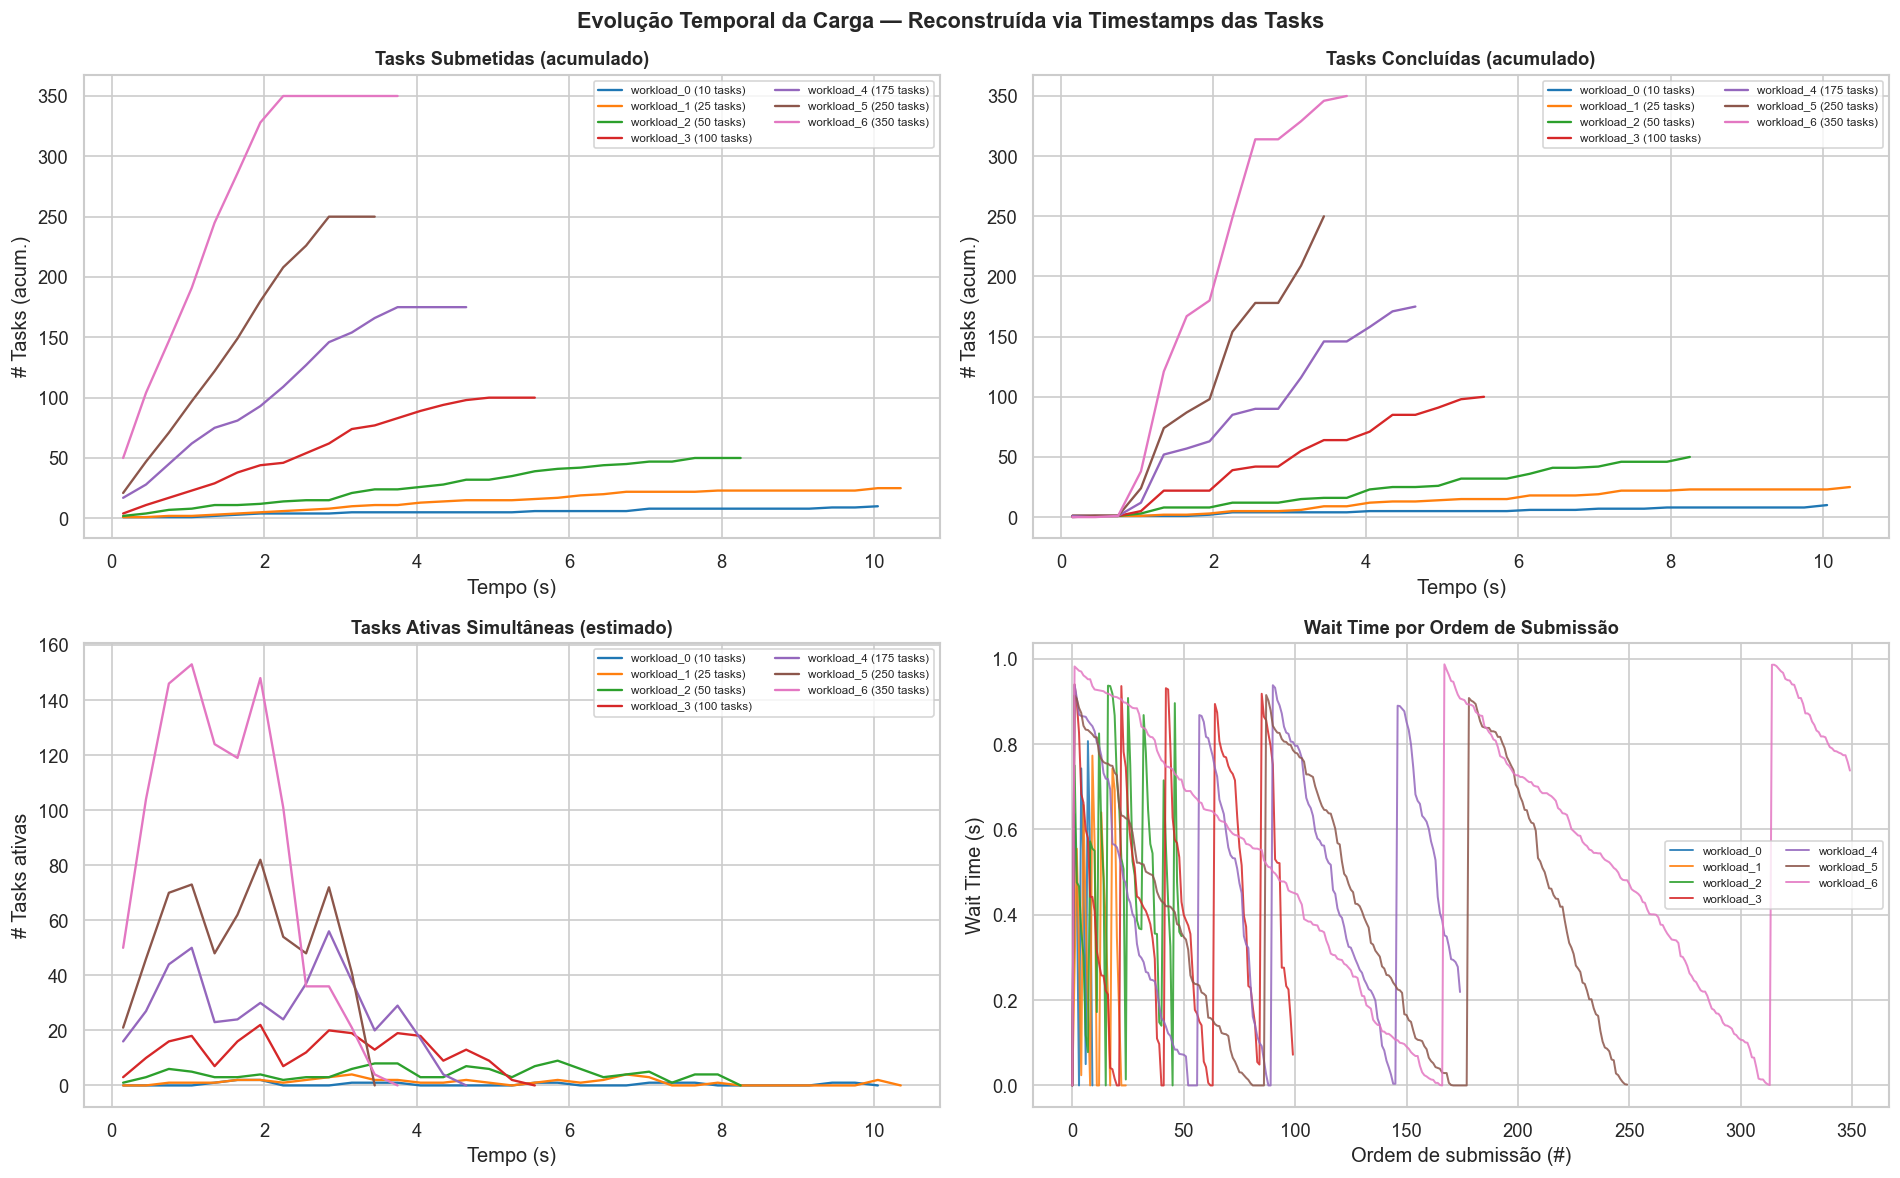

Saved figures/temporal_tasks.png


In [124]:
def task_arrival_curve(df_task_scenario, bin_size_ms=500):
    """Conta tasks chegando e concluindo ao longo do tempo (bins de bin_size_ms)."""
    t_max   = df_task_scenario['finish_time'].max()
    bins    = np.arange(0, t_max + bin_size_ms, bin_size_ms)
    arrival = np.histogram(df_task_scenario['submission_time'], bins=bins)[0]
    finish  = np.histogram(df_task_scenario['finish_time'],     bins=bins)[0]
    t_mid   = (bins[:-1] + bins[1:]) / 2 / 1000   # centro do bin em segundos
    active  = np.cumsum(arrival) - np.cumsum(finish)
    return t_mid, arrival, finish, active

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Evolução Temporal da Carga — Reconstruída via Timestamps das Tasks',
             fontsize=13, fontweight='bold')

for i, scenario in enumerate(SCENARIO_ORDER):
    tk  = df_task[df_task['scenario'] == scenario]
    t, arr, fin, act = task_arrival_curve(tk, bin_size_ms=300)
    c   = colors[i]
    lbl = f'{scenario} ({len(tk)} tasks)'

    axes[0,0].plot(t, np.cumsum(arr), color=c, label=lbl, linewidth=1.4)
    axes[0,1].plot(t, np.cumsum(fin), color=c, label=lbl, linewidth=1.4)
    axes[1,0].plot(t, act.clip(min=0), color=c, label=lbl, linewidth=1.4)

# Painel de wait_time por ordem de submission
for i, scenario in enumerate(SCENARIO_ORDER):
    tk = df_task[df_task['scenario'] == scenario].sort_values('submission_time').reset_index(drop=True)
    axes[1,1].plot(tk.index, tk['wait_time_s'], color=colors[i],
                   label=f'{scenario}', linewidth=1.2, alpha=0.85)

titles = [
    ('Tasks Submetidas (acumulado)', '# Tasks (acum.)'),
    ('Tasks Concluídas (acumulado)', '# Tasks (acum.)'),
    ('Tasks Ativas Simultâneas (estimado)', '# Tasks ativas'),
    ('Wait Time por Ordem de Submissão', 'Wait Time (s)'),
]
xlabels = ['Tempo (s)', 'Tempo (s)', 'Tempo (s)', 'Ordem de submissão (#)']
for ax, (title, ylabel), xl in zip(axes.flat, titles, xlabels):
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xl)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'temporal_tasks.png', dpi=150)
plt.show()
print('Saved figures/temporal_tasks.png')

### 7.3 — Distribuições de latência e execução (boxplot e histograma)

A análise de distribuições complementa as médias apresentadas na tabela-resumo,
expondo a variabilidade interna de cada cenário. Médias semelhantes entre
cenários distintos podem ocultar distribuições muito diferentes — um cenário
com wait time médio baixo pode ainda apresentar caudas longas que impactam
a experiência de usuário em momentos de pico. Os boxplots e histogramas a
seguir permitem identificar assimetrias, outliers e sobreposições entre
os regimes operacionais simulados.

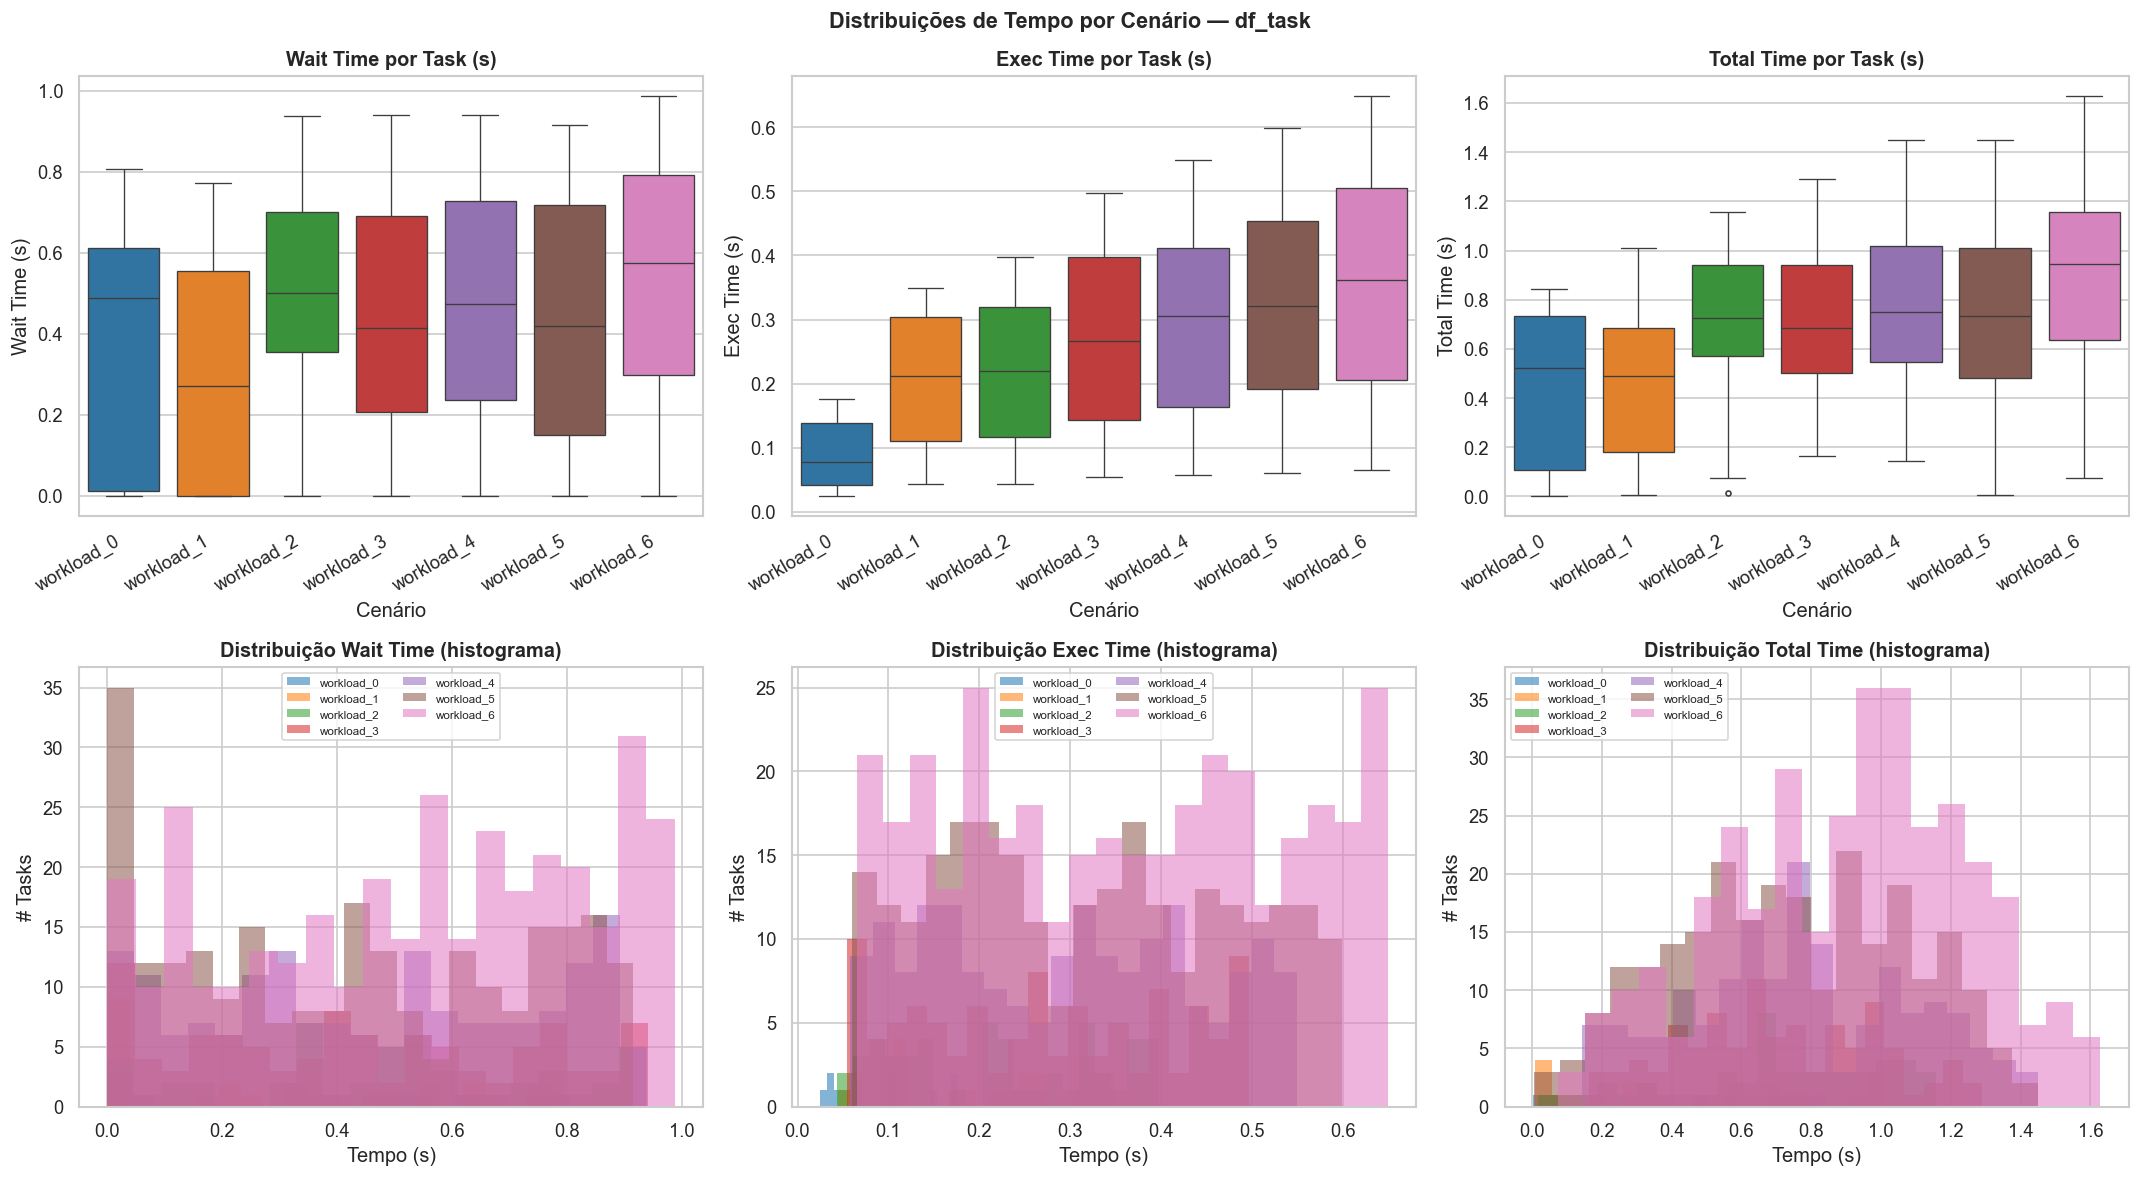

Saved figures/distributions_latency.png


In [125]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuições de Tempo por Cenário — df_task', fontsize=13, fontweight='bold')

for metric, ax, title, ylabel in [
    ('wait_time_s',  axes[0,0], 'Wait Time por Task (s)',    'Wait Time (s)'),
    ('exec_time_s',  axes[0,1], 'Exec Time por Task (s)',    'Exec Time (s)'),
    ('total_time_s', axes[0,2], 'Total Time por Task (s)',   'Total Time (s)'),
]:
    sns.boxplot(data=df_task, x='scenario', y=metric, order=SCENARIO_ORDER,
                palette='tab10', ax=ax, linewidth=0.8, fliersize=3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cenário')
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Histogramas sobrepostos por cenário
for metric, ax, title in [
    ('wait_time_s',  axes[1,0], 'Distribuição Wait Time (histograma)'),
    ('exec_time_s',  axes[1,1], 'Distribuição Exec Time (histograma)'),
    ('total_time_s', axes[1,2], 'Distribuição Total Time (histograma)'),
]:
    for i, scenario in enumerate(SCENARIO_ORDER):
        vals = df_task[df_task['scenario'] == scenario][metric]
        ax.hist(vals, bins=20, alpha=0.55, label=scenario, color=colors[i], edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('# Tasks')
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'distributions_latency.png', dpi=150)
plt.show()
print('Saved figures/distributions_latency.png')

### 7.4 — Perfil dos hosts (snapshot final)

O perfil dos hosts no snapshot final reflete o estado da infraestrutura ao
término de cada simulação. Como os DataFrames de `host.parquet` contêm uma
observação por host ao final da execução, esta análise caracteriza como
a carga se distribui entre as máquinas do cluster em cada cenário —
evidenciando quais hosts concentram maior demanda de CPU e energia, e como
esse padrão evolui à medida que o volume de workload aumenta.

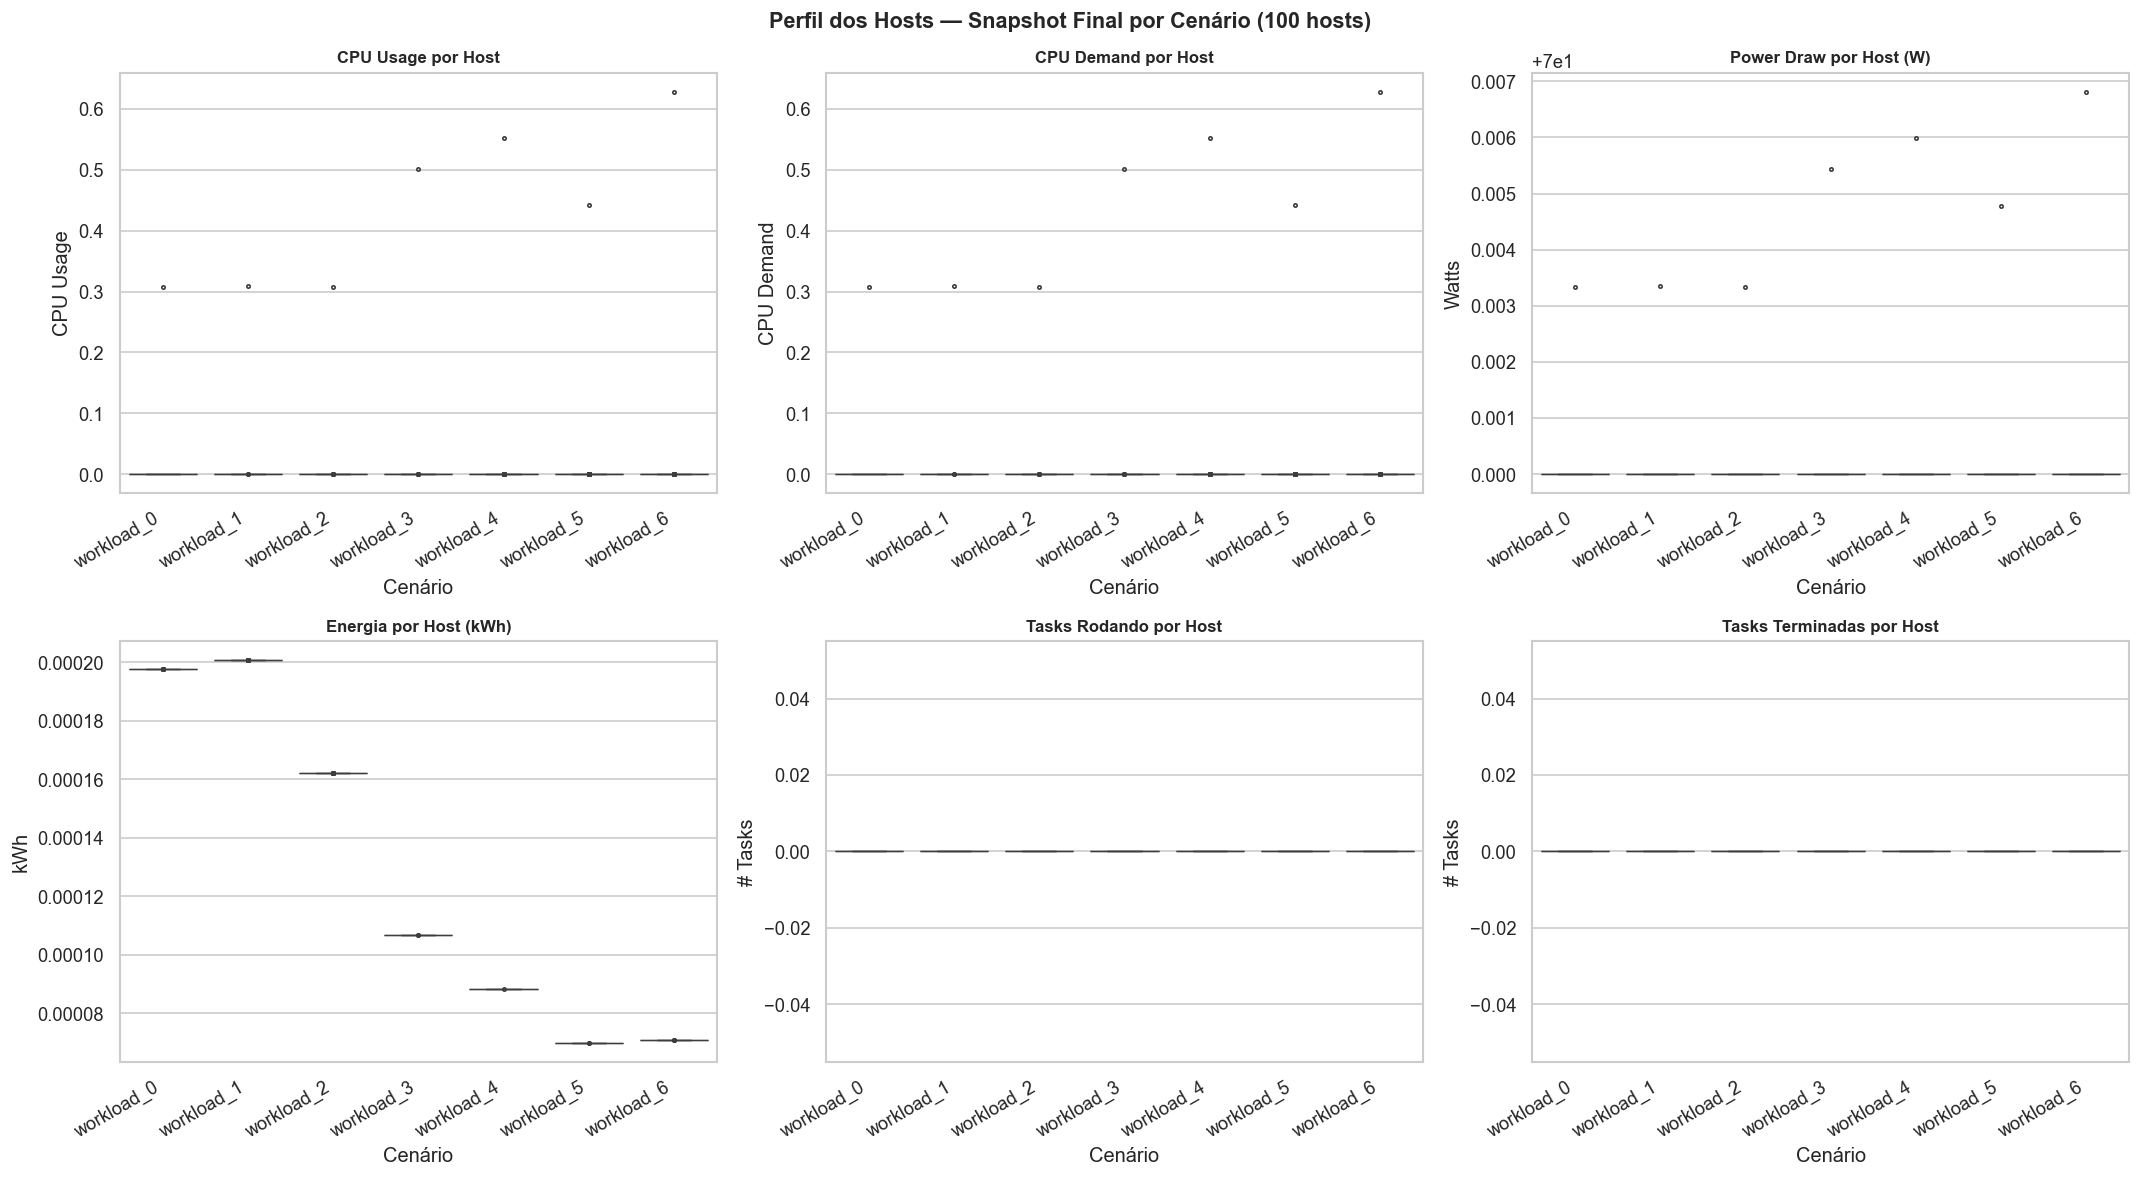

Saved figures/host_profiles.png


In [126]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perfil dos Hosts — Snapshot Final por Cenário (100 hosts)', fontsize=13, fontweight='bold')

host_metrics = [
    ('cpu_usage',      axes[0,0], 'CPU Usage por Host',         'CPU Usage'),
    ('cpu_demand',     axes[0,1], 'CPU Demand por Host',        'CPU Demand'),
    ('power_draw',     axes[0,2], 'Power Draw por Host (W)',    'Watts'),
    ('energy_kwh',     axes[1,0], 'Energia por Host (kWh)',     'kWh'),
    ('tasks_running',  axes[1,1], 'Tasks Rodando por Host',     '# Tasks'),
    ('tasks_terminated', axes[1,2], 'Tasks Terminadas por Host', '# Tasks'),
]

for metric, ax, title, ylabel in host_metrics:
    sns.boxplot(data=df_host, x='scenario', y=metric, order=SCENARIO_ORDER,
                palette='tab10', ax=ax, linewidth=0.8, fliersize=2)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Cenário')
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'host_profiles.png', dpi=150)
plt.show()
print('Saved figures/host_profiles.png')

### 7.5 — Relações entre métricas (dispersão e tendência)

Os gráficos de dispersão a seguir investigam as relações estruturais entre
pares de métricas agregadas por cenário. O objetivo é identificar
dependências que possam informar o modelo preditivo nas etapas seguintes:
se energia e volume de tasks exibem relação linear, por exemplo, um modelo
simples pode ser suficiente para essa variável; relações não lineares ou
com baixa correlação apontam para maior complexidade de modelagem. A linha
de tendência exibida em cada painel é um ajuste linear de referência.

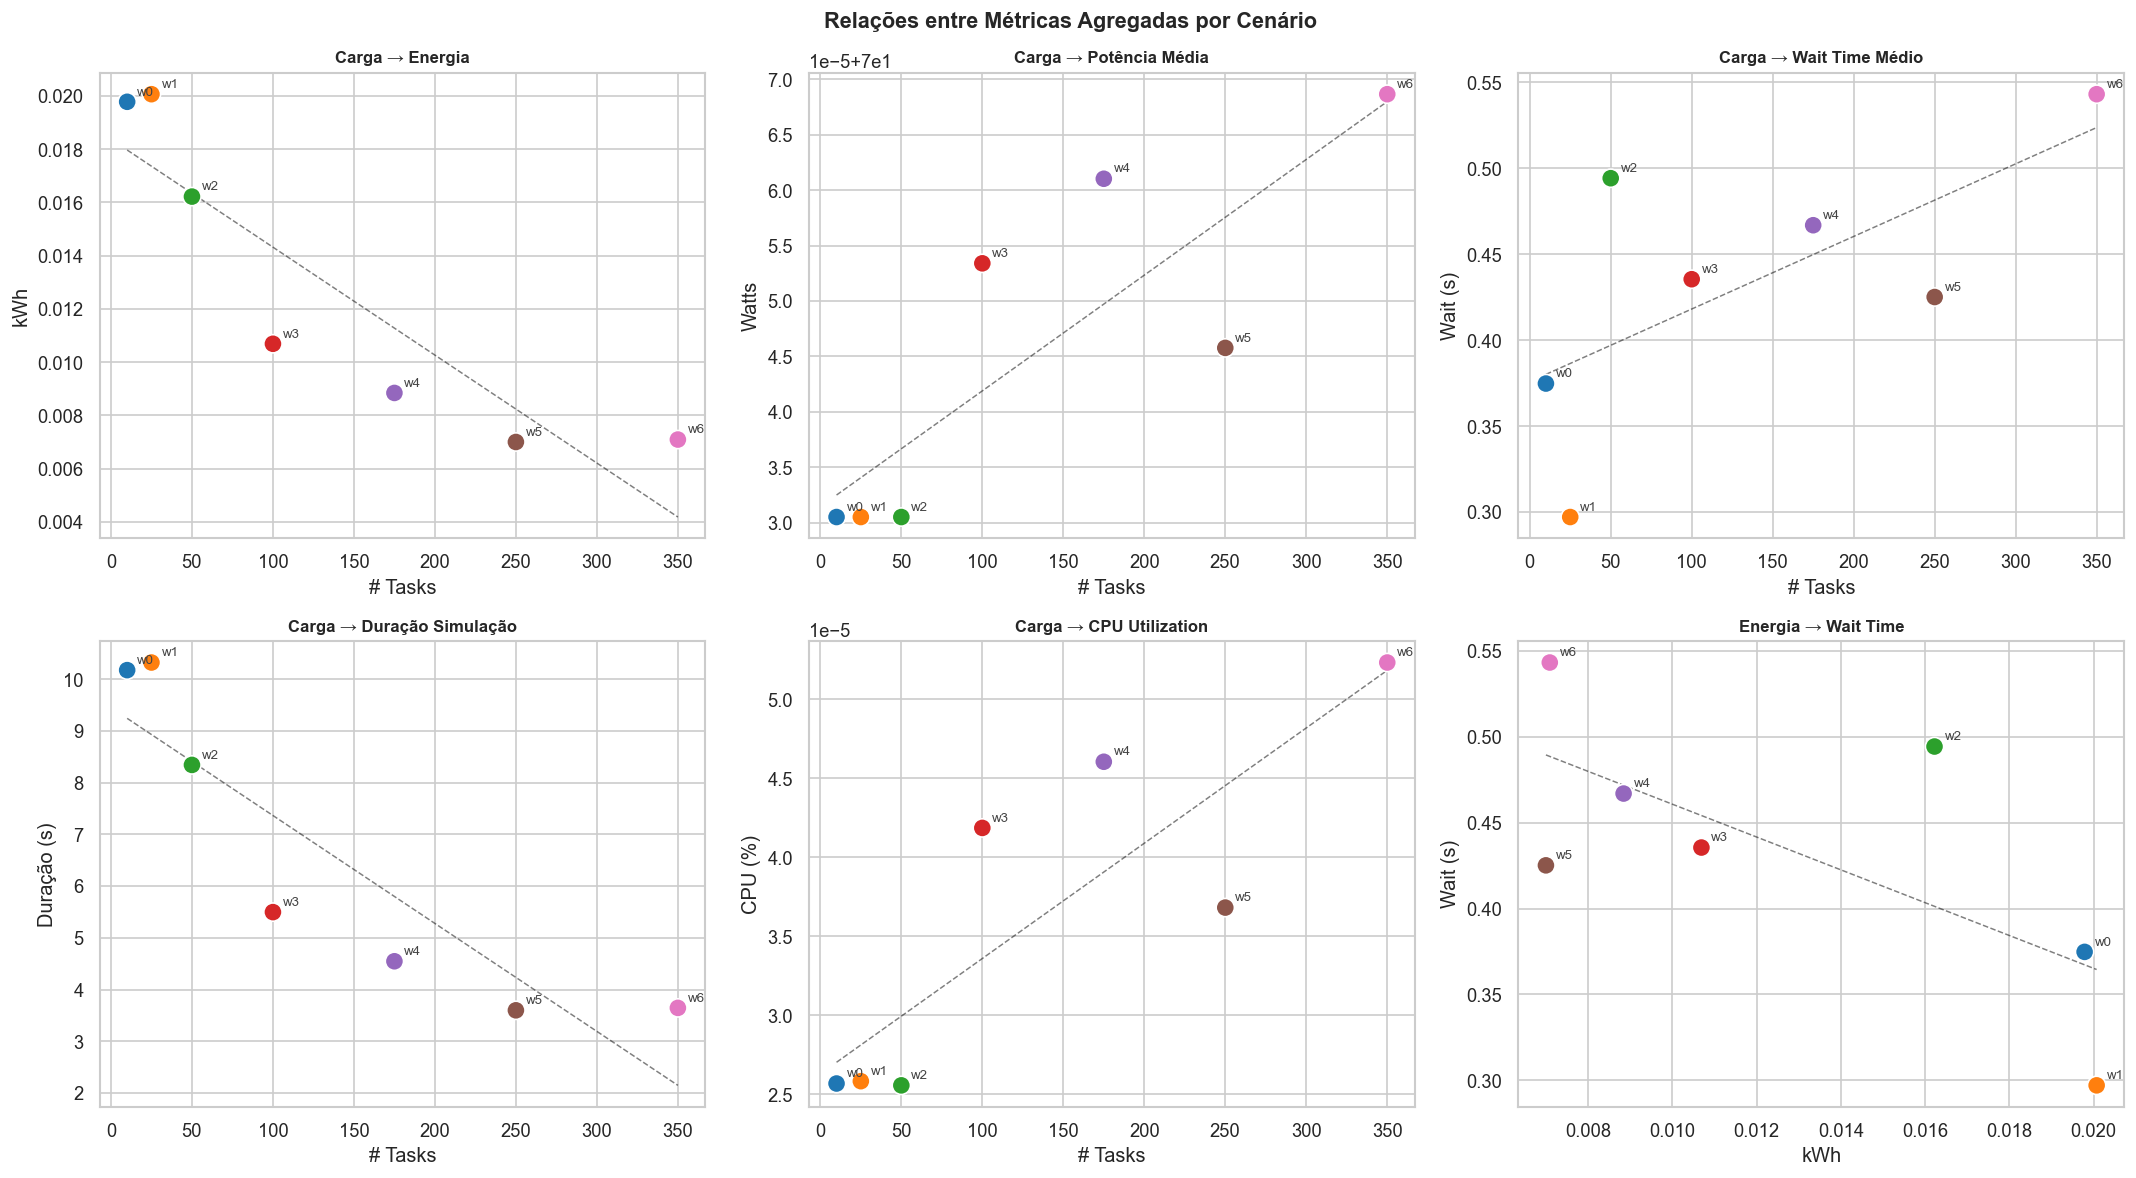

Saved figures/scatter_relations.png


In [127]:
# Tabela de nível cenário para scatter entre variáveis agregadas
df_agg = pd.DataFrame({
    'scenario':       SCENARIO_ORDER,
    'n_tasks':        n_tasks_vals,
    'energy_kwh':     energy_vals,
    'power_w':        power_vals,
    'cpu_util_pct':   cpu_util_vals,
    'wait_mean_s':    wait_vals,
    'exec_mean_s':    exec_vals,
    'total_mean_s':   total_vals,
    'duration_s':     duration_vals,
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relações entre Métricas Agregadas por Cenário', fontsize=13, fontweight='bold')

scatter_pairs = [
    ('n_tasks', 'energy_kwh',   'Carga → Energia',           '# Tasks', 'kWh'),
    ('n_tasks', 'power_w',      'Carga → Potência Média',    '# Tasks', 'Watts'),
    ('n_tasks', 'wait_mean_s',  'Carga → Wait Time Médio',   '# Tasks', 'Wait (s)'),
    ('n_tasks', 'duration_s',   'Carga → Duração Simulação', '# Tasks', 'Duração (s)'),
    ('n_tasks', 'cpu_util_pct', 'Carga → CPU Utilization',   '# Tasks', 'CPU (%)'),
    ('energy_kwh', 'wait_mean_s', 'Energia → Wait Time',     'kWh',     'Wait (s)'),
]

for ax, (x, y, title, xlabel, ylabel) in zip(axes.flat, scatter_pairs):
    ax.scatter(df_agg[x], df_agg[y], c=colors[:len(df_agg)], s=120, zorder=3, edgecolors='white')
    for _, row in df_agg.iterrows():
        ax.annotate(row['scenario'].replace('workload_', 'w'),
                    (row[x], row[y]), textcoords='offset points',
                    xytext=(6, 4), fontsize=8, color='#444')
    # Linha de tendência
    z = np.polyfit(df_agg[x], df_agg[y], 1)
    p = np.poly1d(z)
    ax.plot(sorted(df_agg[x]), p(sorted(df_agg[x])), 'k--', linewidth=0.9, alpha=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'scatter_relations.png', dpi=150)
plt.show()
print('Saved figures/scatter_relations.png')

### 7.6 — Curva de escalabilidade: como cada métrica cresce com a carga

As curvas de escalabilidade examinam como três métricas centrais — energia
total, latência média de espera e duração da simulação — respondem ao
crescimento do volume de carga. O comportamento dessas curvas tem implicação
direta para o gêmeo digital: se a relação for aproximadamente linear, o
sistema pode interpolar previsões com confiança; desvios da linearidade
indicam regimes de operação não triviais que exigem modelagem mais cuidadosa
ou perfis de alerta distintos para diferentes faixas de carga.

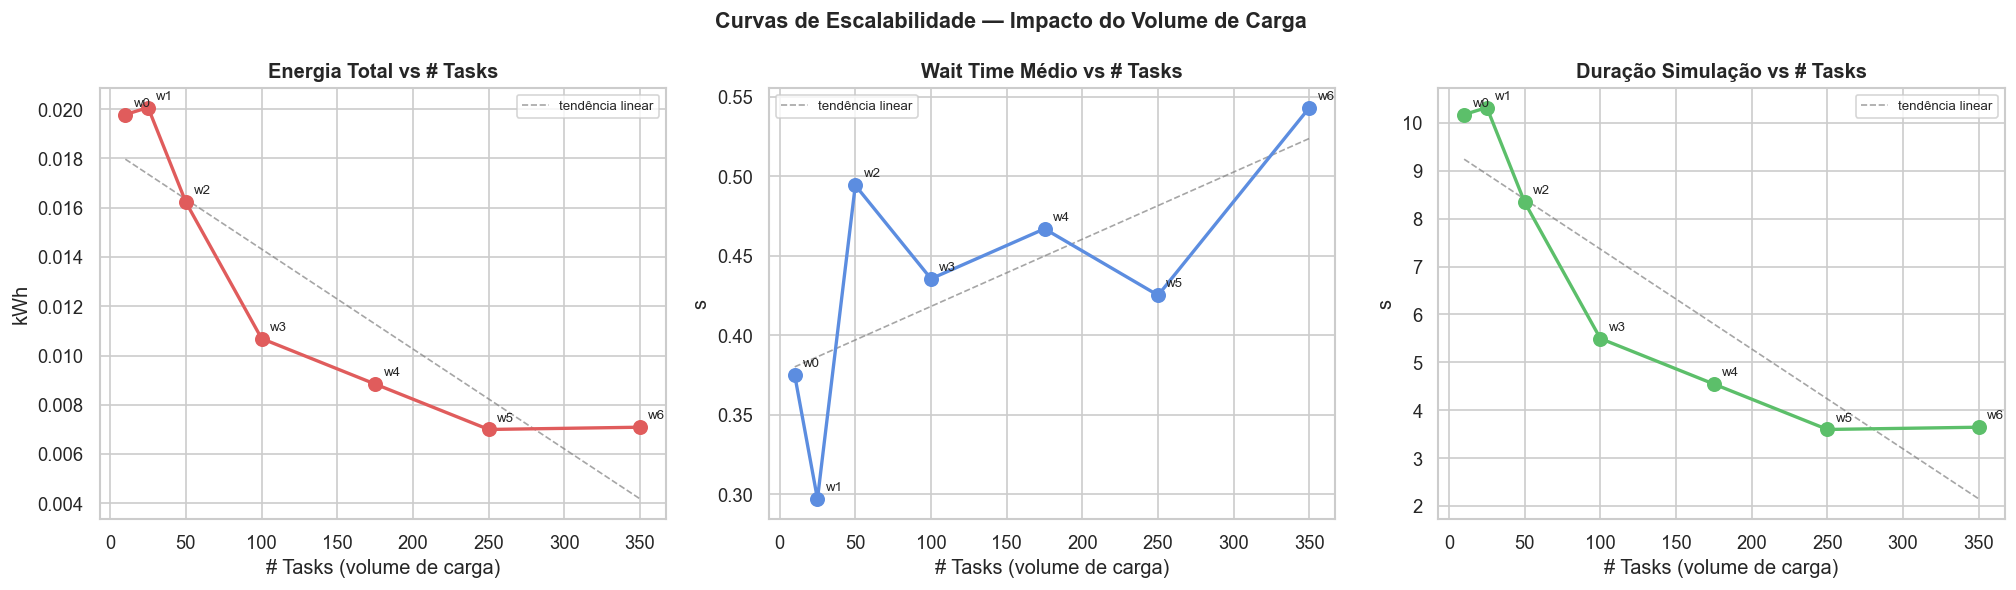

Saved figures/scalability_curves.png


In [128]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Curvas de Escalabilidade — Impacto do Volume de Carga', fontsize=13, fontweight='bold')

x = np.array(n_tasks_vals)

for ax, y_vals, title, ylabel, color in [
    (axes[0], energy_vals,   'Energia Total vs # Tasks',    'kWh',    '#E05C5C'),
    (axes[1], wait_vals,     'Wait Time Médio vs # Tasks',  's',      '#5C8DE0'),
    (axes[2], duration_vals, 'Duração Simulação vs # Tasks','s',      '#5CBF6A'),
]:
    y = np.array(y_vals)
    ax.plot(x, y, 'o-', color=color, linewidth=2, markersize=8, zorder=3)
    for xi, yi, s in zip(x, y, SCENARIO_ORDER):
        ax.annotate(s.replace('workload_','w'), (xi, yi),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)
    # Ajuste linear
    z = np.polyfit(x, y, 1)
    ax.plot(x, np.poly1d(z)(x), '--', color='gray', linewidth=1, alpha=0.7, label='tendência linear')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('# Tasks (volume de carga)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'scalability_curves.png', dpi=150)
plt.show()
print('Saved figures/scalability_curves.png')

### 7.7 — Análise de eficiência: tasks por kWh e custo por task

A eficiência energética — medida como número de tasks concluídas por kWh
consumido e como energia por task individual — é uma das métricas de maior
relevância para o objetivo de otimização de custos do projeto. Um e-commerce
que opera com baixa eficiência energética em regimes de carga moderada
representa uma oportunidade direta de right-sizing identificável pelo gêmeo
digital. A análise a seguir quantifica essa eficiência ao longo dos sete
cenários e a coloca em perspectiva com a potência média consumida por host.

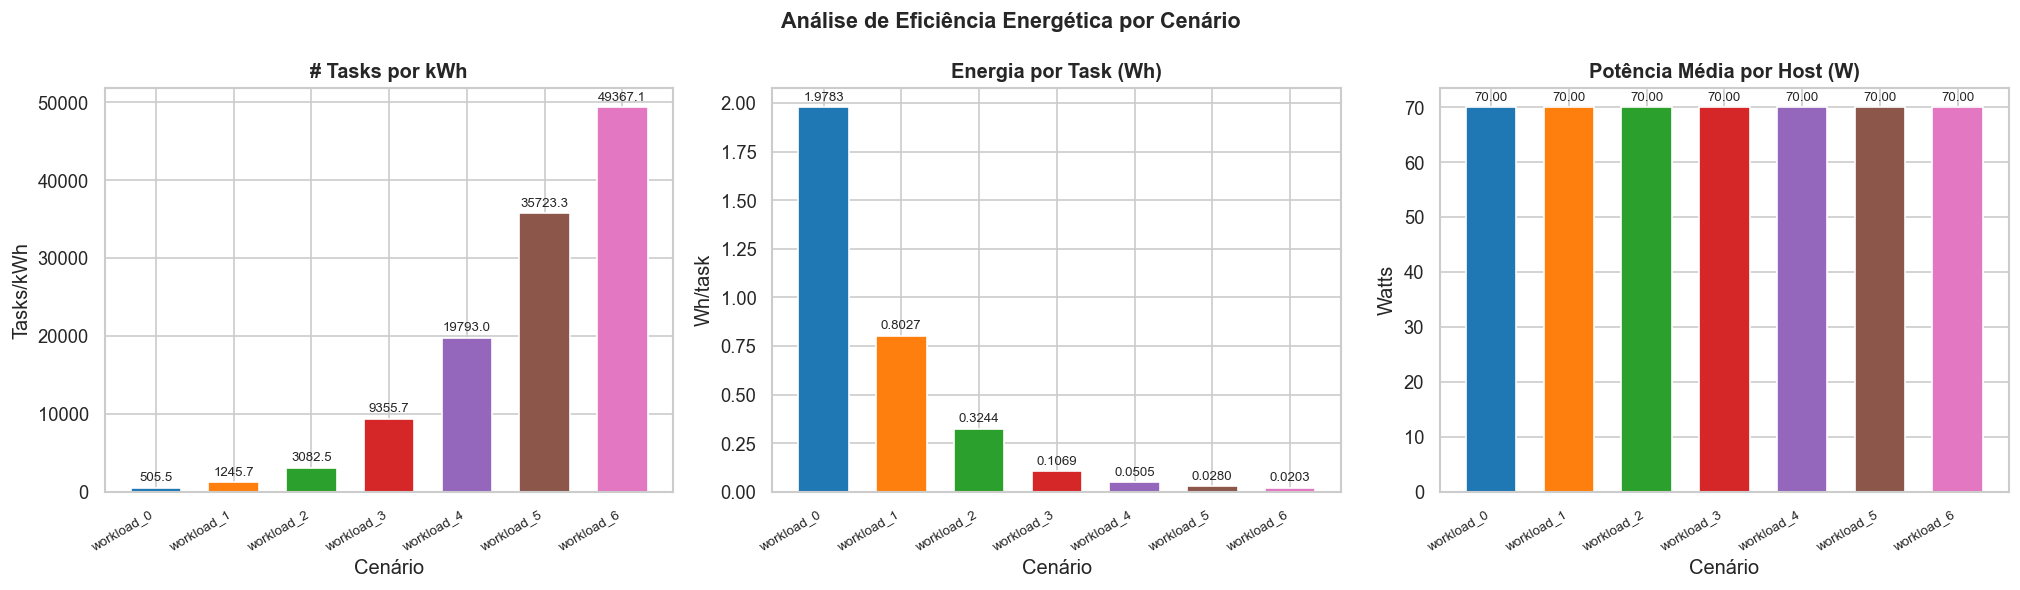

Saved figures/efficiency_analysis.png


In [129]:
df_eff = df_agg.copy()
df_eff['tasks_per_kwh']  = df_eff['n_tasks'] / df_eff['energy_kwh']
df_eff['energy_per_task']= df_eff['energy_kwh'] / df_eff['n_tasks'] * 1000  # Wh/task

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Análise de Eficiência Energética por Cenário', fontsize=13, fontweight='bold')

for ax, col, title, ylabel, fmt in [
    (axes[0], 'tasks_per_kwh',   '# Tasks por kWh',           'Tasks/kWh',  '{:.1f}'),
    (axes[1], 'energy_per_task', 'Energia por Task (Wh)',      'Wh/task',    '{:.4f}'),
    (axes[2], 'power_w',         'Potência Média por Host (W)','Watts',      '{:.2f}'),
]:
    vals = df_eff.set_index('scenario')[col].reindex(SCENARIO_ORDER)
    bars = ax.bar(x_pos, vals.values, color=colors, edgecolor='white', width=0.65)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + vals.values.max()*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SCENARIO_ORDER, rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Cenário')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'efficiency_analysis.png', dpi=150)
plt.show()
print('Saved figures/efficiency_analysis.png')

### 7.8 — Decomposição do tempo da task: wait vs exec vs overhead

A decomposição do tempo total de cada task em suas parcelas de espera
(*wait time*) e execução (*exec time*) permite distinguir ineficiências de
escalonamento de ineficiências de processamento. Um wait time proporcionalmente
elevado indica que o escalonador enfrenta contenção de recursos — situação
característica de cenários de alta demanda como Cyber Monday e Black Friday.
Essa distinção é relevante para o gêmeo digital, pois orienta recomendações
diferentes: problemas de wait time apontam para necessidade de escalonamento
mais agressivo ou provisionamento adicional, enquanto problemas de exec time
sugerem ajustes na alocação de CPU por task.

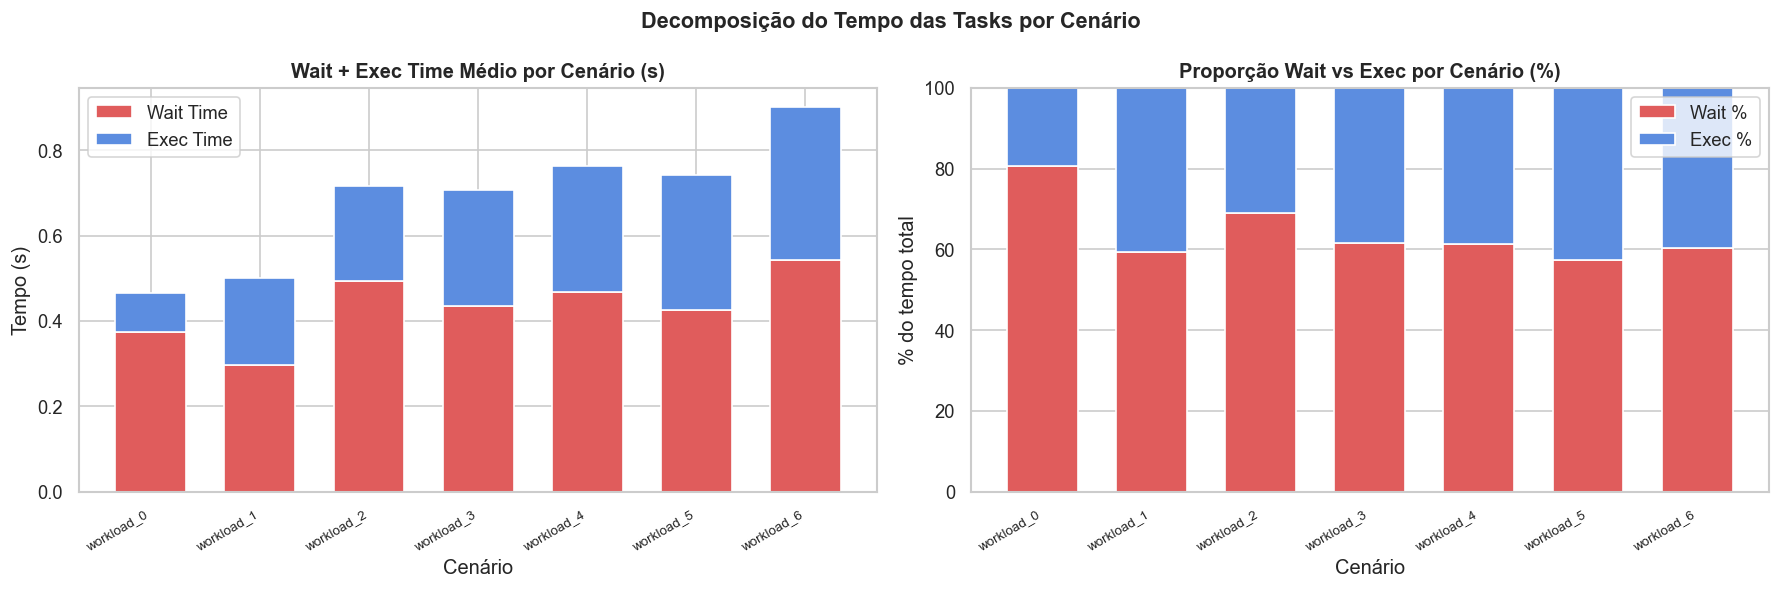

Saved figures/time_decomposition.png


In [130]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Decomposição do Tempo das Tasks por Cenário', fontsize=13, fontweight='bold')

# Barras empilhadas: wait + exec = total
w_means = [df_task[df_task['scenario']==s]['wait_time_s'].mean() for s in SCENARIO_ORDER]
e_means = [df_task[df_task['scenario']==s]['exec_time_s'].mean() for s in SCENARIO_ORDER]

axes[0].bar(x_pos, w_means, label='Wait Time',  color='#E05C5C', edgecolor='white', width=0.65)
axes[0].bar(x_pos, e_means, bottom=w_means, label='Exec Time', color='#5C8DE0', edgecolor='white', width=0.65)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(SCENARIO_ORDER, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Wait + Exec Time Médio por Cenário (s)', fontweight='bold')
axes[0].set_ylabel('Tempo (s)')
axes[0].set_xlabel('Cenário')
axes[0].legend()

# Proporção de wait vs exec (%) 
total_m = [w + e for w, e in zip(w_means, e_means)]
wait_pct = [w/t*100 if t > 0 else 0 for w, t in zip(w_means, total_m)]
exec_pct = [e/t*100 if t > 0 else 0 for e, t in zip(e_means, total_m)]

axes[1].bar(x_pos, wait_pct, label='Wait %', color='#E05C5C', edgecolor='white', width=0.65)
axes[1].bar(x_pos, exec_pct, bottom=wait_pct, label='Exec %', color='#5C8DE0', edgecolor='white', width=0.65)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(SCENARIO_ORDER, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Proporção Wait vs Exec por Cenário (%)', fontweight='bold')
axes[1].set_ylabel('% do tempo total')
axes[1].set_xlabel('Cenário')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'time_decomposition.png', dpi=150)
plt.show()
print('Saved figures/time_decomposition.png')

### 7.9 — Distribuição de tasks por host (balanceamento de carga)

O balanceamento de carga entre hosts é um indicador indireto da eficácia da
política de escalonamento adotada pelo simulador. Distribuições muito
assimétricas sugerem que parte da infraestrutura permanece ociosa mesmo sob
carga elevada, representando desperdício de recursos — exatamente o tipo de
ineficiência que o gêmeo digital adaptável se propõe a identificar e reportar
de forma contextualizada.

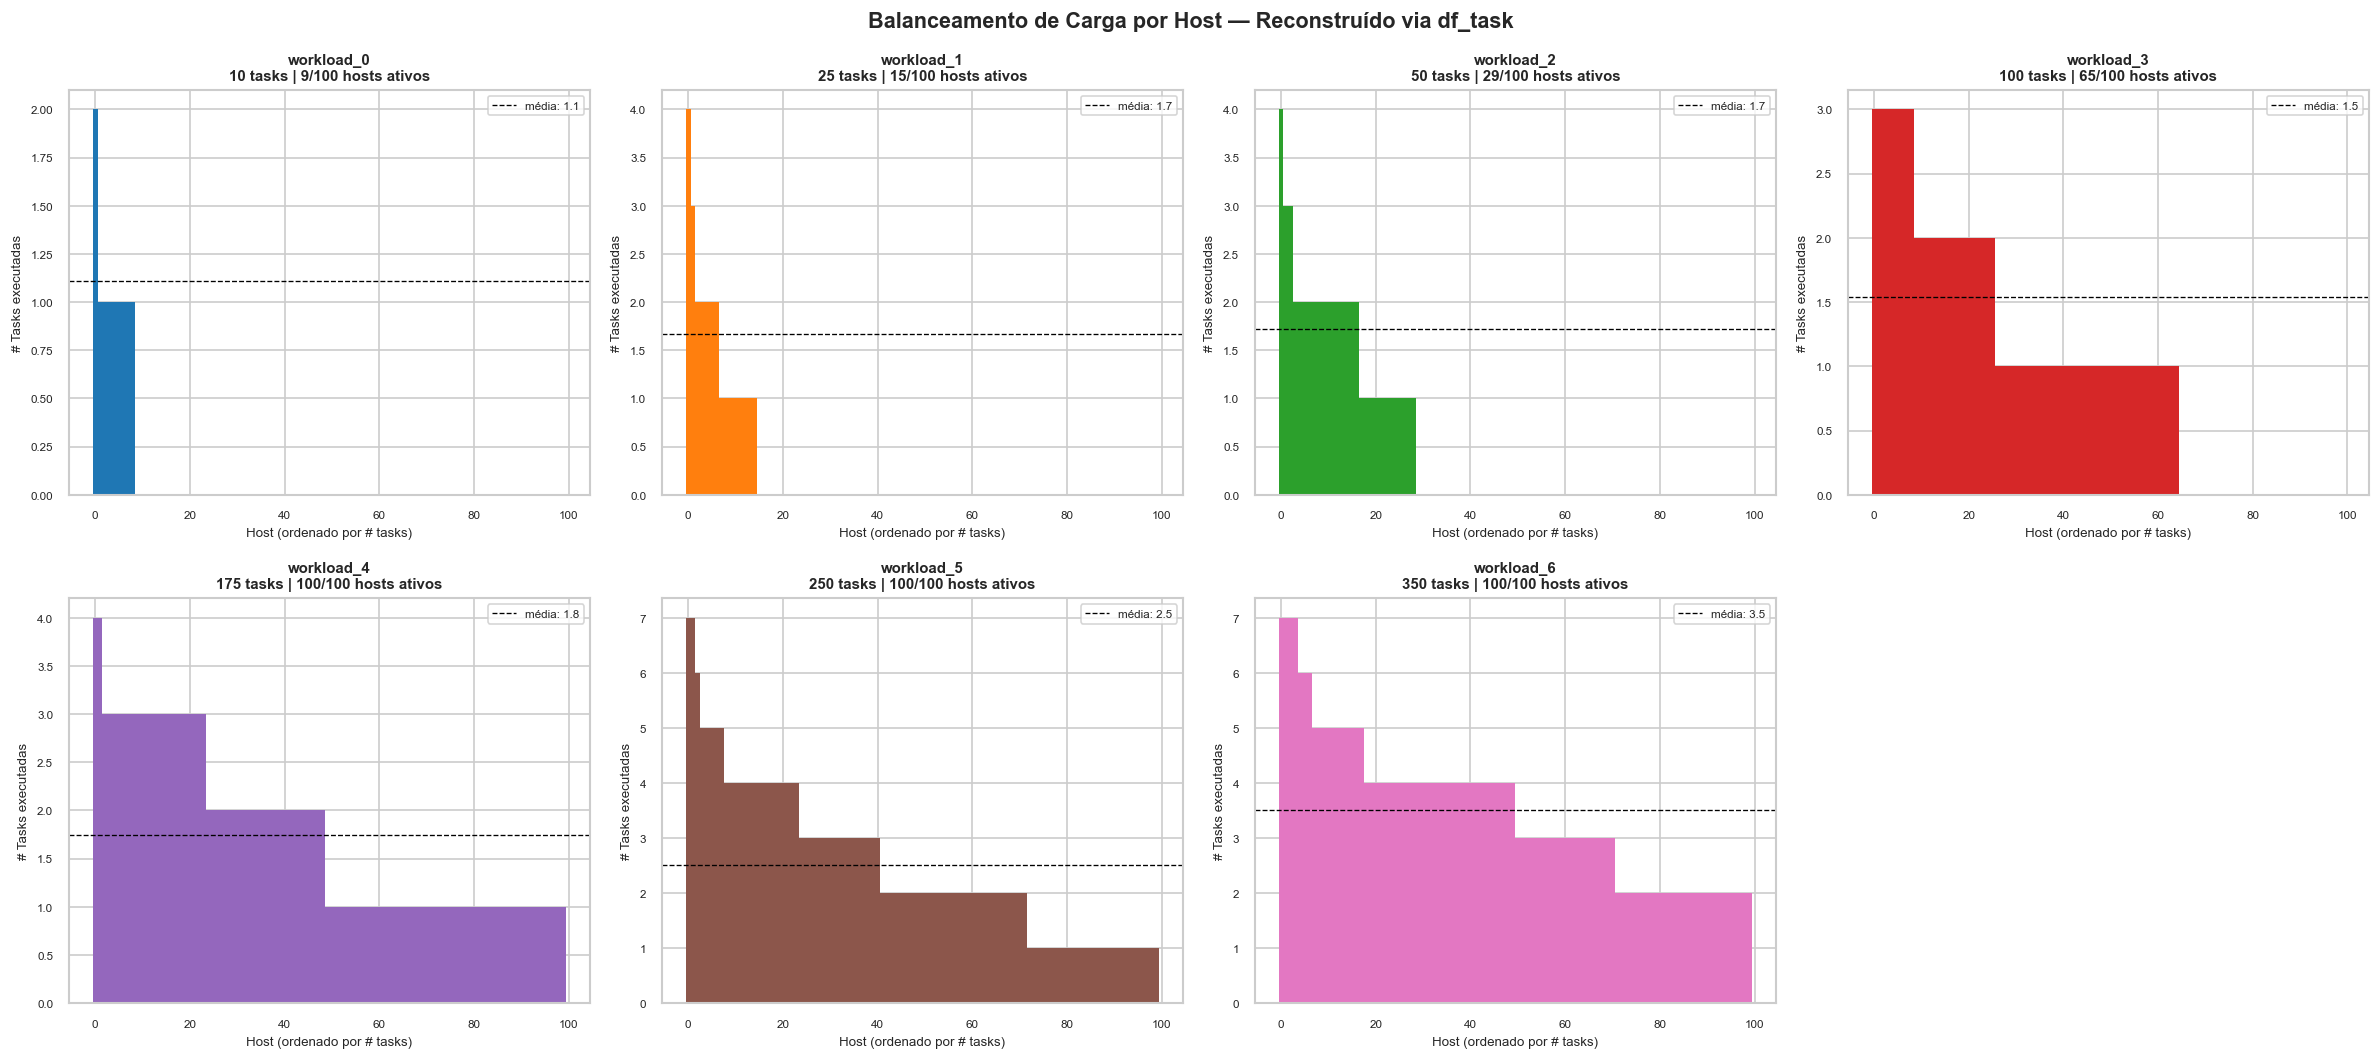

Saved figures/load_balance_per_host.png

📊 Resumo do balanceamento:


,n_tasks,hosts_ativos,max_tasks_host,min_tasks_host,media_tasks,std_tasks
scenario,,,,,,
workload_0,10,9,2,1,1.1100,0.3300
workload_1,25,15,4,1,1.6700,0.9000
workload_2,50,29,4,1,1.7200,0.7500
workload_3,100,65,3,1,1.5400,0.7300
workload_4,175,100,4,1,1.7500,0.8700
workload_5,250,100,7,1,2.5000,1.4000
workload_6,350,100,7,2,3.5000,1.3100


In [131]:
# Contar tasks por host a partir de df_task
tasks_per_host = (
    df_task.groupby(['scenario', 'host_name'])
    .size()
    .reset_index(name='n_tasks')
)

# Total de hosts conhecidos (do df_host)
all_hosts_per_scenario = (
    df_host.groupby('scenario')['host_name']
    .apply(list).to_dict()
)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Balanceamento de Carga por Host — Reconstruído via df_task',
             fontsize=13, fontweight='bold')

axes_flat = list(axes.flat)
for i, scenario in enumerate(SCENARIO_ORDER):
    ax = axes_flat[i]

    # Tasks por host neste cenário, preenchendo zeros para hosts sem tasks
    tph = tasks_per_host[tasks_per_host['scenario'] == scenario].set_index('host_name')['n_tasks']
    all_hosts = all_hosts_per_scenario.get(scenario, [])
    tph = tph.reindex(all_hosts, fill_value=0).sort_values(ascending=False).reset_index(drop=True)

    n_active = (tph > 0).sum()
    n_total  = len(tph)

    ax.bar(range(len(tph)), tph.values, color=colors[i], edgecolor='none', width=1.0)
    ax.set_title(
        f'{scenario}\n{N_TASKS_PER_SCENARIO[scenario]} tasks | {n_active}/{n_total} hosts ativos',
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Host (ordenado por # tasks)', fontsize=8)
    ax.set_ylabel('# Tasks executadas', fontsize=8)
    ax.tick_params(labelsize=7)

    # Linha de média
    mean_val = tph[tph > 0].mean() if n_active > 0 else 0
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=0.8,
               label=f'média: {mean_val:.1f}')
    ax.legend(fontsize=7)

# Esconder o subplot extra (2x4=8, temos 7)
axes_flat[7].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'load_balance_per_host.png', dpi=150)
plt.show()
print('Saved figures/load_balance_per_host.png')

# Tabela de resumo de balanceamento
balance_summary = []
for scenario in SCENARIO_ORDER:
    tph = tasks_per_host[tasks_per_host['scenario'] == scenario]['n_tasks']
    balance_summary.append({
        'scenario':       scenario,
        'n_tasks':        N_TASKS_PER_SCENARIO[scenario],
        'hosts_ativos':   (tph > 0).sum(),
        'max_tasks_host': tph.max(),
        'min_tasks_host': tph[tph > 0].min() if (tph > 0).any() else 0,
        'media_tasks':    round(tph[tph > 0].mean(), 2) if (tph > 0).any() else 0,
        'std_tasks':      round(tph[tph > 0].std(), 2)  if (tph > 0).any() else 0,
    })

print('\n📊 Resumo do balanceamento:')
display(pd.DataFrame(balance_summary).set_index('scenario'))

### 7.10 — Correlação entre métricas (heatmap)

A matriz de correlação entre métricas agregadas permite identificar
dependências estruturais entre variáveis do sistema. Correlações fortes entre
volume de tasks e consumo energético, por exemplo, validam a coerência
física das simulações; correlações inesperadas podem indicar artefatos do
modelo ou comportamentos emergentes da política de escalonamento do OpenDC.

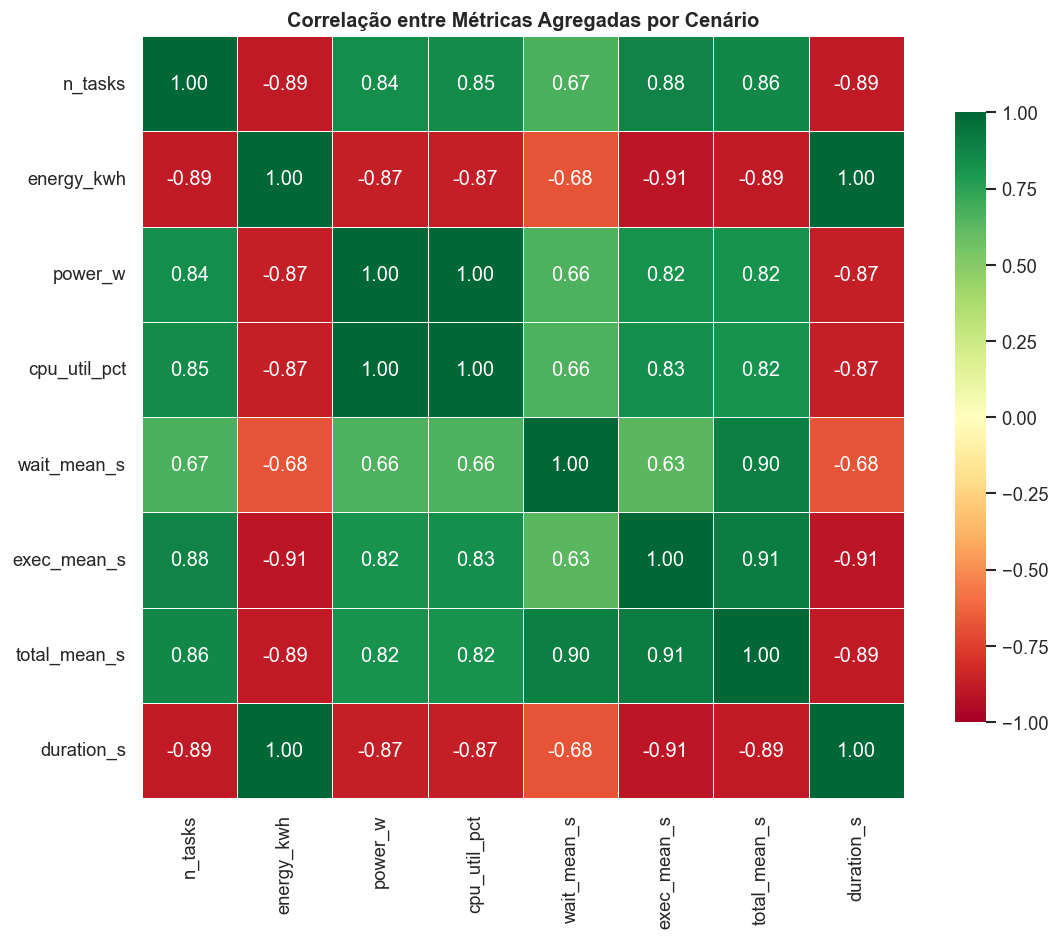

Saved figures/correlation_heatmap.png

 Matriz de correlação:


,n_tasks,energy_kwh,power_w,cpu_util_pct,wait_mean_s,exec_mean_s,total_mean_s,duration_s
n_tasks,1.0000,-0.8900,0.8400,0.8500,0.6700,0.8800,0.8600,-0.8900
energy_kwh,-0.8900,1.0000,-0.8700,-0.8700,-0.6800,-0.9100,-0.8900,1.0000
power_w,0.8400,-0.8700,1.0000,1.0000,0.6600,0.8200,0.8200,-0.8700
cpu_util_pct,0.8500,-0.8700,1.0000,1.0000,0.6600,0.8300,0.8200,-0.8700
wait_mean_s,0.6700,-0.6800,0.6600,0.6600,1.0000,0.6300,0.9000,-0.6800
exec_mean_s,0.8800,-0.9100,0.8200,0.8300,0.6300,1.0000,0.9100,-0.9100
total_mean_s,0.8600,-0.8900,0.8200,0.8200,0.9000,0.9100,1.0000,-0.8900
duration_s,-0.8900,1.0000,-0.8700,-0.8700,-0.6800,-0.9100,-0.8900,1.0000


In [132]:
# Correlação entre variáveis agregadas de nível cenário
corr_cols = ['n_tasks', 'energy_kwh', 'power_w', 'cpu_util_pct',
             'wait_mean_s', 'exec_mean_s', 'total_mean_s', 'duration_s']
corr_matrix = df_agg[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlação entre Métricas Agregadas por Cenário', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()
print('Saved figures/correlation_heatmap.png')
print('\n Matriz de correlação:')
display(corr_matrix)

---
## Bloco 8 — Métricas Derivadas por Cenário

In [133]:
records = []

for scenario in SCENARIO_NAMES:
    h  = df_host [df_host ['scenario'] == scenario]
    pw = df_power[df_power['scenario'] == scenario]
    sv = df_svc  [df_svc  ['scenario'] == scenario]
    tk = df_task [df_task ['scenario'] == scenario]

    sim_duration_h     = h['time_s'].max() / 3600
    n_hosts            = h['host_name'].nunique()   # hosts totais no cluster

    # Hosts que efetivamente executaram tasks (do df_task)
    # Correto: cobrar apenas hosts ativos, não o cluster inteiro
    n_hosts_active     = tk['host_name'].nunique() if not tk.empty else 0

    # Host
    cpu_util_mean  = h['cpu_util_pct'].mean()
    cpu_util_p95   = h['cpu_util_pct'].quantile(0.95)
    cpu_util_max   = h['cpu_util_pct'].max()
    power_mean_w   = h['power_draw'].mean()

    # Energia (valor máximo acumulado = total da simulação)
    energy_total_kwh  = pw['energy_kwh'].max()
    carbon_emission_g = pw['carbon_emission'].max()

    # Custo estimado: apenas hosts ativos × duração da simulação × preço/h
    # Fonte do preço: AWS Pricing API (ver pricing/pricing_metadata.json)
    estimated_cost_usd = n_hosts_active * sim_duration_h * EC2_PRICE_USD_PER_H

    # Service
    tasks_total        = int(sv['tasks_total'].max())
    tasks_completed    = int(sv['tasks_completed'].max())
    tasks_pending_max  = int(sv['tasks_pending'].max())
    saturation_pct     = tasks_pending_max / tasks_total * 100 if tasks_total > 0 else 0

    # Task (última observação de cada task_id)
    tk_final        = tk.sort_values('time_s').groupby('task_id').last()
    n_unique_tasks  = len(tk_final)
    wait_mean_s     = tk_final['wait_time_s'].mean()
    wait_p95_s      = tk_final['wait_time_s'].quantile(0.95)
    exec_mean_s     = tk_final['exec_time_s'].mean()
    total_time_mean = tk_final['total_time_s'].mean()
    completion_rate = tk_final['completed'].mean() * 100
    failure_rate    = (tk_final['num_failures'] > 0).mean() * 100

    # Eficiência derivada
    tasks_per_kwh    = tasks_completed / energy_total_kwh if energy_total_kwh > 0 else np.nan
    cost_per_task    = estimated_cost_usd / tasks_completed if tasks_completed > 0 else np.nan

    records.append({
        'scenario':            scenario,
        'sim_duration_h':      round(sim_duration_h,     4),
        'n_hosts':             n_hosts,
        'n_hosts_active':      n_hosts_active,
        'cpu_util_mean_pct':   round(cpu_util_mean,      4),
        'cpu_util_p95_pct':    round(cpu_util_p95,       4),
        'cpu_util_max_pct':    round(cpu_util_max,       4),
        'power_mean_w':        round(power_mean_w,       4),
        'energy_total_kwh':    round(energy_total_kwh,   6),
        'carbon_emission_g':   round(carbon_emission_g,  4),
        'estimated_cost_usd':  round(estimated_cost_usd, 4),
        'tasks_total':         tasks_total,
        'tasks_completed':     tasks_completed,
        'tasks_pending_max':   tasks_pending_max,
        'saturation_pct':      round(saturation_pct,     4),
        'n_unique_tasks':      n_unique_tasks,
        'wait_mean_s':         round(wait_mean_s,        4),
        'wait_p95_s':          round(wait_p95_s,         4),
        'exec_mean_s':         round(exec_mean_s,        4),
        'total_time_mean_s':   round(total_time_mean,    4),
        'completion_rate_pct': round(completion_rate,    4),
        'failure_rate_pct':    round(failure_rate,       4),
        'tasks_per_kwh':       round(tasks_per_kwh,      4),
        'cost_per_task_usd':   round(cost_per_task,      6),
    })

df_derived = pd.DataFrame(records)
print(' Métricas derivadas por cenário:')
display(df_derived)

 Métricas derivadas por cenário:


,scenario,sim_duration_h,n_hosts,n_hosts_active,cpu_util_mean_pct,cpu_util_p95_pct,cpu_util_max_pct,power_mean_w,energy_total_kwh,carbon_emission_g,estimated_cost_usd,tasks_total,tasks_completed,tasks_pending_max,saturation_pct,n_unique_tasks,wait_mean_s,wait_p95_s,exec_mean_s,total_time_mean_s,completion_rate_pct,failure_rate_pct,tasks_per_kwh,cost_per_task_usd
0,workload_0,0.0028,100,9,0.0000,0.0000,0.0026,70.0000,0.0198,0.0000,0.0048,10,10,0,0.0000,10,0.3748,0.7782,0.0905,0.4458,100.0000,0.0000,505.4902,0.0005
1,workload_1,0.0029,100,15,0.0000,0.0000,0.0026,70.0000,0.0201,0.0000,0.0082,25,25,0,0.0000,25,0.2971,0.7330,0.2030,0.4744,100.0000,0.0000,1245.7261,0.0003
2,workload_2,0.0023,100,29,0.0000,0.0000,0.0026,70.0000,0.0162,0.0000,0.0128,50,50,0,0.0000,50,0.4943,0.9135,0.2210,0.7128,100.0000,0.0000,3082.5051,0.0003
3,workload_3,0.0015,100,65,0.0000,0.0000,0.0042,70.0001,0.0107,0.0000,0.0189,100,100,0,0.0000,100,0.4355,0.8990,0.2710,0.7045,100.0000,0.0000,9355.7083,0.0002
4,workload_4,0.0013,100,100,0.0000,0.0000,0.0046,70.0001,0.0088,0.0000,0.0240,175,175,0,0.0000,175,0.4669,0.8788,0.2949,0.7602,100.0000,0.0000,19793.0306,0.0001
5,workload_5,0.0010,100,100,0.0000,0.0000,0.0037,70.0000,0.0070,0.0000,0.0190,250,250,0,0.0000,250,0.4252,0.8490,0.3172,0.7405,100.0000,0.0000,35723.2675,0.0001
6,workload_6,0.0010,100,100,0.0001,0.0000,0.0052,70.0001,0.0071,0.0000,0.0193,350,350,0,0.0000,350,0.5432,0.9511,0.3578,0.9010,100.0000,0.0000,49367.0835,0.0001


---
## Bloco 9 — Consolidação do Dataset Final

In [134]:
df_final = df_derived.copy()
df_final['topology']         = 'm7i.xlarge'
df_final['instance_vcpus']   = 4
df_final['instance_ram_gib'] = 16
df_final['provider']         = 'AWS EC2'
df_final['price_usd_per_h']  = EC2_PRICE_USD_PER_H
df_final['seed']             = 0

id_cols  = ['scenario', 'topology', 'provider', 'instance_vcpus',
            'instance_ram_gib', 'price_usd_per_h', 'seed']
met_cols = [c for c in df_final.columns if c not in id_cols]
df_final = df_final[id_cols + met_cols]

print(f' Dataset final: {len(df_final)} cenários × {len(df_final.columns)} colunas')
display(df_final.T)

df_final.to_csv(DATASETS_DIR / 'opendc_consolidated.csv', index=False)
df_final.to_parquet(DATASETS_DIR / 'opendc_consolidated.parquet', index=False)
print(f'\n Saved datasets/opendc_consolidated.csv')
print(f'Saved datasets/opendc_consolidated.parquet')

 Dataset final: 7 cenários × 30 colunas


,0,1,2,3,4,5,6
scenario,workload_0,workload_1,workload_2,workload_3,workload_4,workload_5,workload_6
topology,m7i.xlarge,m7i.xlarge,m7i.xlarge,m7i.xlarge,m7i.xlarge,m7i.xlarge,m7i.xlarge
provider,AWS EC2,AWS EC2,AWS EC2,AWS EC2,AWS EC2,AWS EC2,AWS EC2
instance_vcpus,4,4,4,4,4,4,4
instance_ram_gib,16,16,16,16,16,16,16
price_usd_per_h,0.1904,0.1904,0.1904,0.1904,0.1904,0.1904,0.1904
seed,0,0,0,0,0,0,0
sim_duration_h,0.0028,0.0029,0.0023,0.0015,0.0013,0.0010,0.0010
n_hosts,100,100,100,100,100,100,100
n_hosts_active,9,15,29,65,100,100,100



 Saved datasets/opendc_consolidated.csv
Saved datasets/opendc_consolidated.parquet


---
## Bloco 10 — Preparação para Modelagem

### 10.1 — Features e Targets

In [135]:
# ── Features: descrevem o workload / cenário de entrada ───────────────────────
FEATURE_COLS = [
    'n_unique_tasks',    # volume de tasks únicas submetidas
    'exec_mean_s',       # duração média de execução de cada task
    'sim_duration_h',    # duração total da simulação
    'n_hosts',           # número de hosts ativos
]

# ── Targets: variáveis que o modelo deve prever ───────────────────────────────
TARGET_COLS = [
    'energy_total_kwh',    # consumo energético total do cluster
    'cpu_util_mean_pct',   # utilização média de CPU
    'estimated_cost_usd',  # custo estimado EC2
    'wait_mean_s',         # latência média das tasks
    'saturation_pct',      # saturação máxima do scheduler
    'completion_rate_pct', # taxa de completude das tasks
]

df_ml = df_final[['scenario'] + FEATURE_COLS + TARGET_COLS].copy()
df_ml.to_csv(DATASETS_DIR / 'opendc_ml_ready.csv', index=False)

print(' Features:')
for f in FEATURE_COLS: print(f'   • {f}')
print('\n Targets:')
for t in TARGET_COLS:  print(f'   • {t}')
print(f'\n Saved datasets/opendc_ml_ready.csv')
display(df_ml)

 Features:
   • n_unique_tasks
   • exec_mean_s
   • sim_duration_h
   • n_hosts

 Targets:
   • energy_total_kwh
   • cpu_util_mean_pct
   • estimated_cost_usd
   • wait_mean_s
   • saturation_pct
   • completion_rate_pct

 Saved datasets/opendc_ml_ready.csv


,scenario,n_unique_tasks,exec_mean_s,sim_duration_h,n_hosts,energy_total_kwh,cpu_util_mean_pct,estimated_cost_usd,wait_mean_s,saturation_pct,completion_rate_pct
0,workload_0,10,0.0905,0.0028,100,0.0198,0.0000,0.0048,0.3748,0.0000,100.0000
1,workload_1,25,0.2030,0.0029,100,0.0201,0.0000,0.0082,0.2971,0.0000,100.0000
2,workload_2,50,0.2210,0.0023,100,0.0162,0.0000,0.0128,0.4943,0.0000,100.0000
3,workload_3,100,0.2710,0.0015,100,0.0107,0.0000,0.0189,0.4355,0.0000,100.0000
4,workload_4,175,0.2949,0.0013,100,0.0088,0.0000,0.0240,0.4669,0.0000,100.0000
5,workload_5,250,0.3172,0.0010,100,0.0070,0.0000,0.0190,0.4252,0.0000,100.0000
6,workload_6,350,0.3578,0.0010,100,0.0071,0.0001,0.0193,0.5432,0.0000,100.0000


### 10.2 — Considerações Metodológicas

Os dados consolidados neste notebook constituem a base empírica inicial do
projeto, mas suas limitações devem ser explicitadas para orientar a
interpretação dos resultados e o planejamento das etapas seguintes.

O dataset compreende sete cenários de simulação, volume que, embora suficiente
para análise exploratória e validação conceitual, é insuficiente para o
treinamento de modelos de aprendizado de máquina de maior complexidade. Para
as etapas de modelagem preditiva, recomenda-se a expansão da base por meio de
interpolação paramétrica entre workloads, execução com múltiplas seeds ou
geração de cenários intermediários, de modo a ampliar a variabilidade dos
dados sem comprometer a reprodutibilidade experimental.

As colunas de GPU presentes em `task.parquet` estão inteiramente zeradas neste
experimento, o que reflete a ausência de workloads GPU-intensivos no perfil do
case modelado. Essas colunas devem ser desconsideradas na modelagem.

O custo estimado foi calculado com base em preços oficiais da AWS Pricing API
para a instância `m7i.xlarge` na região `us-east-1`, carregados do snapshot
local em `pricing/pricing_metadata.json`. Variações cambiais, modelos de
precificação sob reserva ou spot, e custos de rede e armazenamento não estão
contemplados nesta estimativa, que deve ser tratada como aproximação de
referência, não como projeção financeira precisa.

A coluna `scenario` presente em todos os DataFrames garante rastreabilidade
completa: qualquer predição ou recomendação produzida nas etapas seguintes
pode ser vinculada ao cenário de origem e ao arquivo `.parquet` correspondente,
preservando a cadeia de evidências exigida pela metodologia experimental do
projeto.

## Bloco 10.3 — Limitações e Direções Futuras

### Limitações desta Etapa

Os resultados apresentados neste notebook derivam exclusivamente de dados
simulados, produzidos pelo OpenDC sobre uma topologia configurada para
aproximar as características da instância Amazon EC2 `m7i.xlarge`. Embora
o simulador permita reprodutibilidade experimental e controle preciso das
condições de teste — vantagens relevantes para a fase inicial do projeto —
sua fidelidade em relação ao comportamento de infraestrutura real é
inerentemente limitada. Aspectos como latência de rede, variabilidade de
desempenho entre instâncias físicas, políticas de escalonamento do
hipervisor do provedor e eventos imprevisíveis de infraestrutura não são
capturados pelo modelo de simulação.

Os experimentos foram conduzidos com seed única (`seed=0`), o que limita
a avaliação da variabilidade estocástica dos resultados. A execução com
múltiplas seeds é recomendada antes de qualquer inferência estatística
mais rigorosa sobre os valores obtidos.

Por fim, este notebook documenta apenas uma das seis topologias definidas
no projeto. As demais topologias, correspondentes a outros perfis de
instância EC2, serão analisadas em notebooks análogos, e os resultados
consolidados permitirão comparações entre configurações de infraestrutura
distintas.

### Direções para as Etapas Seguintes

A partir da base estruturada produzida aqui, as próximas etapas do projeto
compreendem: o desenvolvimento de modelos preditivos para energia, custo e
latência; a implementação do sistema de recomendação de configurações
parametrizado por restrições operacionais do cliente; e a integração desses
componentes na interface do gêmeo digital adaptável. Os experimentos
comparativos entre configurações genéricas e adaptadas ao perfil do
e-commerce, previstos na Fase 4 do plano de trabalho, utilizarão os
datasets consolidados aqui como linha de base.

---
## Bloco 11 — Resumo de Execução

In [136]:
figs = list(FIGURES_DIR.glob('*.png'))
print('='*65)
print('RESUMO DE EXECUÇÃO')
print('='*65)
print(f'  Data/hora            : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Instância simulada   : m7i.xlarge (4 vCPU / 16 GiB RAM)')
print(f'  Cenários analisados  : {len(SCENARIO_NAMES)}')
for s in SCENARIO_NAMES: print(f'    └── {s}')
print(f'  Linhas — host        : {len(df_host):>9,}')
print(f'  Linhas — powerSource : {len(df_power):>9,}')
print(f'  Linhas — service     : {len(df_svc):>9,}')
print(f'  Linhas — task        : {len(df_task):>9,}')
print(f'  Dataset consolidado  : {len(df_final)} × {len(df_final.columns)} colunas')
print(f'  Dataset ML           : {len(df_ml)} × {len(df_ml.columns)} colunas')
print(f'  Figuras salvas       : {len(figs)}')
for f in figs: print(f'    └── {f.name}')
print('='*65)

RESUMO DE EXECUÇÃO
  Data/hora            : 2026-04-16 02:02:52
  Instância simulada   : m7i.xlarge (4 vCPU / 16 GiB RAM)
  Cenários analisados  : 7
    └── workload_0
    └── workload_1
    └── workload_2
    └── workload_3
    └── workload_4
    └── workload_5
    └── workload_6
  Linhas — host        :       700
  Linhas — powerSource :         7
  Linhas — service     :         7
  Linhas — task        :       960
  Dataset consolidado  : 7 × 30 colunas
  Dataset ML           : 7 × 11 colunas
  Figuras salvas       : 10
    └── bar_comparison_full.png
    └── correlation_heatmap.png
    └── distributions_latency.png
    └── efficiency_analysis.png
    └── host_profiles.png
    └── load_balance_per_host.png
    └── scalability_curves.png
    └── scatter_relations.png
    └── temporal_tasks.png
    └── time_decomposition.png


## Referências

OPENDC. OpenDC: Open Datacenter Simulator. Disponível em:
https://opendc.org. Acesso em: nov. 2025.

AMAZON WEB SERVICES. AWS Pricing API — EC2 Instance Pricing.
Disponível em: https://aws.amazon.com/ec2/pricing/on-demand.
Acesso em: nov. 2025.

FUJII, T. Y. et al. A Digital Twin Architecture Model Applied with MLOps
Techniques to Improve Short-Term Energy Consumption Prediction.
*Machines*, v. 10, n. 1, art. 23, 2021.
DOI: 10.3390/machines10010023.

INTERNATIONAL ORGANIZATION FOR STANDARDIZATION; INTERNATIONAL
ELECTROTECHNICAL COMMISSION. *ISO/IEC 25010*: Systems and software
Quality Requirements and Evaluation (SQuaRE). Geneva: ISO/IEC, 2023.

BASS, L.; CLEMENTS, P.; KAZMAN, R. *Software Architecture in Practice*.
4. ed. Upper Saddle River: Addison-Wesley, 2021.

FLEXERA. *2025 State of the Cloud Report*. Flexera, 2025.
Disponível em: https://info.flexera.com/CM-REPORT-State-of-the-Cloud.
Acesso em: nov. 2025.